# Employee Performance Analysis – INX Future Inc.

---

## 1. Project Overview

INX Future Inc., a leading analytics and automation solutions provider, has recently observed a decline in employee performance levels. Service delivery escalations have increased and client satisfaction has dropped by 8 percentage points. 

The objective of this project is to analyze the existing employee data to:

- Understand department-wise performance trends  
- Identify the key factors influencing employee performance  
- Build a predictive model to classify employee performance  
- Provide actionable recommendations to management  

This analysis aims to support data-driven decision-making without negatively impacting employee morale.

---

## 2. Understanding the Dataset

The dataset consists of structured employee-level information, including:

- Demographic attributes  
- Job-related features (department, job role, experience, etc.)  
- Compensation-related factors  
- Work environment indicators  
- Performance ratings  

The target variable for this project is **Employee Performance Rating**, which represents the performance level of each employee.

The dataset contains both categorical and numerical variables, requiring preprocessing before model development.

---

## 3. Data Preprocessing and Preparation

The following steps were performed to prepare the data for analysis and modeling:

### Data Cleaning
- Checked for missing values and inconsistencies.
- Verified categorical value consistency.
- Ensured no duplicate records were present.

### Feature Engineering
- Created meaningful derived features where required.
- Converted categorical variables into numerical format using appropriate encoding techniques.
- Evaluated multicollinearity and removed redundant information where necessary.

### Exploratory Data Analysis (EDA)
- Analyzed distribution of performance ratings.
- Studied department-wise performance trends.
- Examined relationships between employee attributes and performance.
- Identified patterns and potential influencing factors.

EDA helped in understanding which variables show strong association with performance ratings and guided feature selection for modeling.

---

## 4. Model Development Approach

To predict employee performance, multiple tree-based machine learning models were trained and evaluated:

- Decision Tree  
- Random Forest  
- Gradient Boosting  
- XGBoost  

These models were selected because:

- They handle mixed data types effectively.
- They capture non-linear relationships.
- They are robust to feature interactions.
- They provide feature importance insights.

Model performance was evaluated using:

- Accuracy  
- Precision  
- Recall  
- F1 Score  
- Accuracy Gap (to detect overfitting)

Based on comparative analysis, Random Forest was selected as the most suitable model and further optimized using hyperparameter tuning.

---

## 5. Key Focus of the Project

This project focuses on answering the following business questions:

1. Which departments are performing well and which require improvement?
2. What are the top factors affecting employee performance?
3. Can we build a reliable predictive model to identify high and low performers?
4. What strategic actions can management take to improve overall performance?

The ultimate goal is to provide insights that are practical, fair, and aligned with long-term organizational growth.

---

## 6. Summary of Work Performed

In summary, the project followed a structured data science workflow:

1. Data understanding and cleaning  
2. Exploratory data analysis  
3. Feature engineering  
4. Model training and evaluation  
5. Hyperparameter tuning  
6. Interpretation of results and business recommendations  

The analysis combines statistical exploration with machine learning modeling to deliver both insights and predictive capability.

This ensures that management decisions are backed by data rather than assumptions. 

## Importing Necessary Libraries 

In [1]:
# Importing required libraries/modules 
import numpy as np 
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt 

## Loading the Dataset 

In [2]:
# Load the INX Future Inc employee performance dataset into a pandas DataFrame
data = pd.read_csv("INX_Future_Inc_Employee_Performance_CDS_Project2_Data_V1.csv") 

## Basic Check 

In [3]:
pd.set_option('display.max_columns', None) # Ensuring all columns are displayed in the summary (no truncation) 
data.head() # Showing first few rows for a quick glance at structure 

,EmpNumber,Age,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,Attrition,PerformanceRating
0,E1001000,32,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,10,3,4,55,3,2,4,1,No,12,4,10,2,2,10,7,0,8,No,3
1,E1001006,47,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,14,4,4,42,3,2,1,2,No,12,4,20,2,3,7,7,1,7,No,3
2,E1001007,40,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Frequently,5,4,4,48,2,3,1,5,Yes,21,3,20,2,3,18,13,1,12,No,4
3,E1001009,41,Male,Human Resources,Divorced,Human Resources,Manager,Travel_Rarely,10,4,2,73,2,5,4,3,No,15,2,23,2,2,21,6,12,6,No,3
4,E1001010,60,Male,Marketing,Single,Sales,Sales Executive,Travel_Rarely,16,4,1,84,3,2,1,8,No,14,4,10,1,3,2,2,2,2,No,3


In [4]:
data.info() # Inspecting dtypes and non-null counts 

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 28 columns):
 #   Column                        Non-Null Count  Dtype 
---  ------                        --------------  ----- 
 0   EmpNumber                     1200 non-null   object
 1   Age                           1200 non-null   int64 
 2   Gender                        1200 non-null   object
 3   EducationBackground           1200 non-null   object
 4   MaritalStatus                 1200 non-null   object
 5   EmpDepartment                 1200 non-null   object
 6   EmpJobRole                    1200 non-null   object
 7   BusinessTravelFrequency       1200 non-null   object
 8   DistanceFromHome              1200 non-null   int64 
 9   EmpEducationLevel             1200 non-null   int64 
 10  EmpEnvironmentSatisfaction    1200 non-null   int64 
 11  EmpHourlyRate                 1200 non-null   int64 
 12  EmpJobInvolvement             1200 non-null   int64 
 13  EmpJobLevel       

**The dataset contains 1,200 employee records with 28 features. All columns have 1,200 non-null values, indicating that there are `no missing values` present in the dataset. The features include both numerical (`int64`) and categorical (`object`) data types, suggesting that categorical variables will need to be encoded before proceeding to model building.** 

### Descriptive Statistics 

In [5]:
# Format floats to 2 decimal places for cleaner tables
pd.set_option('display.float_format', '{:.2f}'.format)

# Generate descriptive statistics for numerical features
data.describe() 

,Age,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating
count,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00,1200.00
mean,36.92,9.17,2.89,2.72,65.98,2.73,2.07,2.73,2.67,15.22,2.73,11.33,2.79,2.74,7.08,4.29,2.19,4.11,2.95
std,9.09,8.18,1.04,1.09,20.21,0.71,1.11,1.10,2.47,3.63,1.08,7.80,1.26,0.70,6.24,3.61,3.22,3.54,0.52
min,18.00,1.00,1.00,1.00,30.00,1.00,1.00,1.00,0.00,11.00,1.00,0.00,0.00,1.00,0.00,0.00,0.00,0.00,2.00
25%,30.00,2.00,2.00,2.00,48.00,2.00,1.00,2.00,1.00,12.00,2.00,6.00,2.00,2.00,3.00,2.00,0.00,2.00,3.00
50%,36.00,7.00,3.00,3.00,66.00,3.00,2.00,3.00,2.00,14.00,3.00,10.00,3.00,3.00,5.00,3.00,1.00,3.00,3.00
75%,43.00,14.00,4.00,4.00,83.00,3.00,3.00,4.00,4.00,18.00,4.00,15.00,3.00,3.00,10.00,7.00,3.00,7.00,3.00
max,60.00,29.00,5.00,4.00,100.00,4.00,5.00,4.00,9.00,25.00,4.00,40.00,6.00,4.00,40.00,18.00,15.00,17.00,4.00


In [6]:
data.describe(include = "O") # Getting summary statistics to understand categorical distributions 

,EmpNumber,Gender,EducationBackground,MaritalStatus,EmpDepartment,EmpJobRole,BusinessTravelFrequency,OverTime,Attrition
count,1200,1200,1200,1200,1200,1200,1200,1200,1200
unique,1200,2,6,3,6,19,3,2,2
top,E1001000,Male,Life Sciences,Married,Sales,Sales Executive,Travel_Rarely,No,No
freq,1,725,492,548,373,270,846,847,1022


## Data Cleaning 

In [7]:
# Check the total number of duplicate rows in the dataset
data.duplicated().sum() 

0

The dataset was checked for duplicate entries to ensure data integrity. No duplicate rows were found, indicating that each record represents a unique employee and no redundancy is present in the data. 

In [8]:
# Check the distribution of employee performance ratings
# This helps us understand class imbalance in the target variable
data["PerformanceRating"].value_counts() 

PerformanceRating
3    874
2    194
4    132
Name: count, dtype: int64

The majority of employees (874 out of 1200) have a performance rating of 3, followed by 194 employees with rating 2 and 132 employees with rating 4. This indicates a clear class imbalance, with most employees categorized as average performers. Such imbalance should be considered during model training and evaluation, as it may bias the model toward predicting the majority class. 

In [9]:
data.drop("EmpNumber", axis = 1, inplace = True) # Dropping Unnecessary Column 

The column `EmpNumber` is a unique identifier assigned to each employee.
Since it does not carry any meaningful information related to employee performance and will not contribute to predictive modeling, it is removed from the dataset. 

## Exploratory Data Analysis(EDA) 

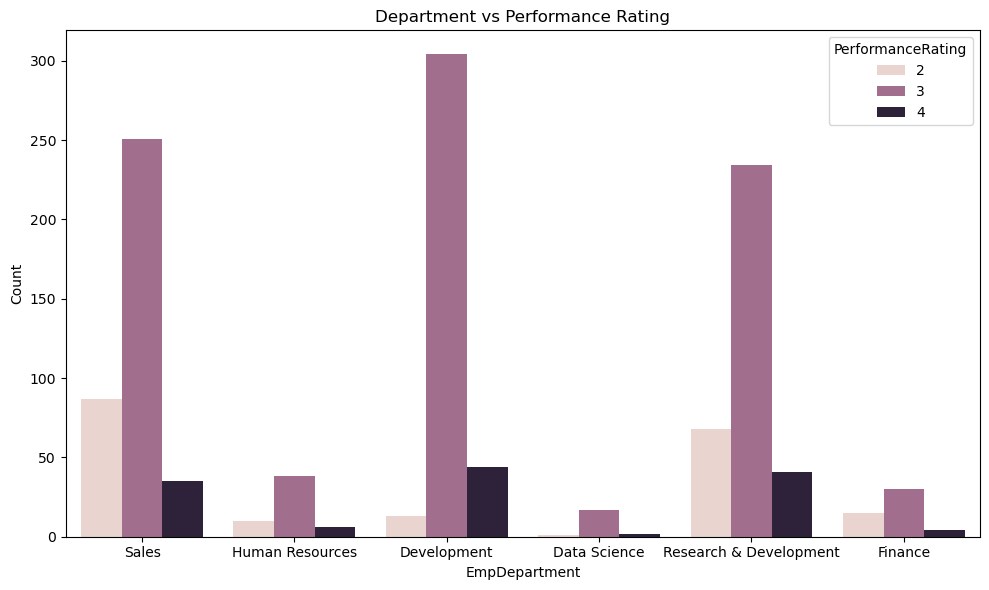

In [10]:
# ===============================
# Department-wise Performance Analysis (Project Goal 1)
# ===============================

# Visualize distribution of performance ratings across different departments
plt.figure(figsize=(10,6))

sns.countplot(x='EmpDepartment', hue='PerformanceRating', data=data)

# Add title and axis labels for business interpretation
plt.title("Department vs Performance Rating")
plt.xlabel("EmpDepartment")
plt.ylabel("Count")

# Rotate x-axis labels for better readability
plt.xticks() 

# Adjust layout to prevent overlapping
plt.tight_layout()
plt.show() 

### Univariate Analysis 

#### 1. For Continuous Columns: 

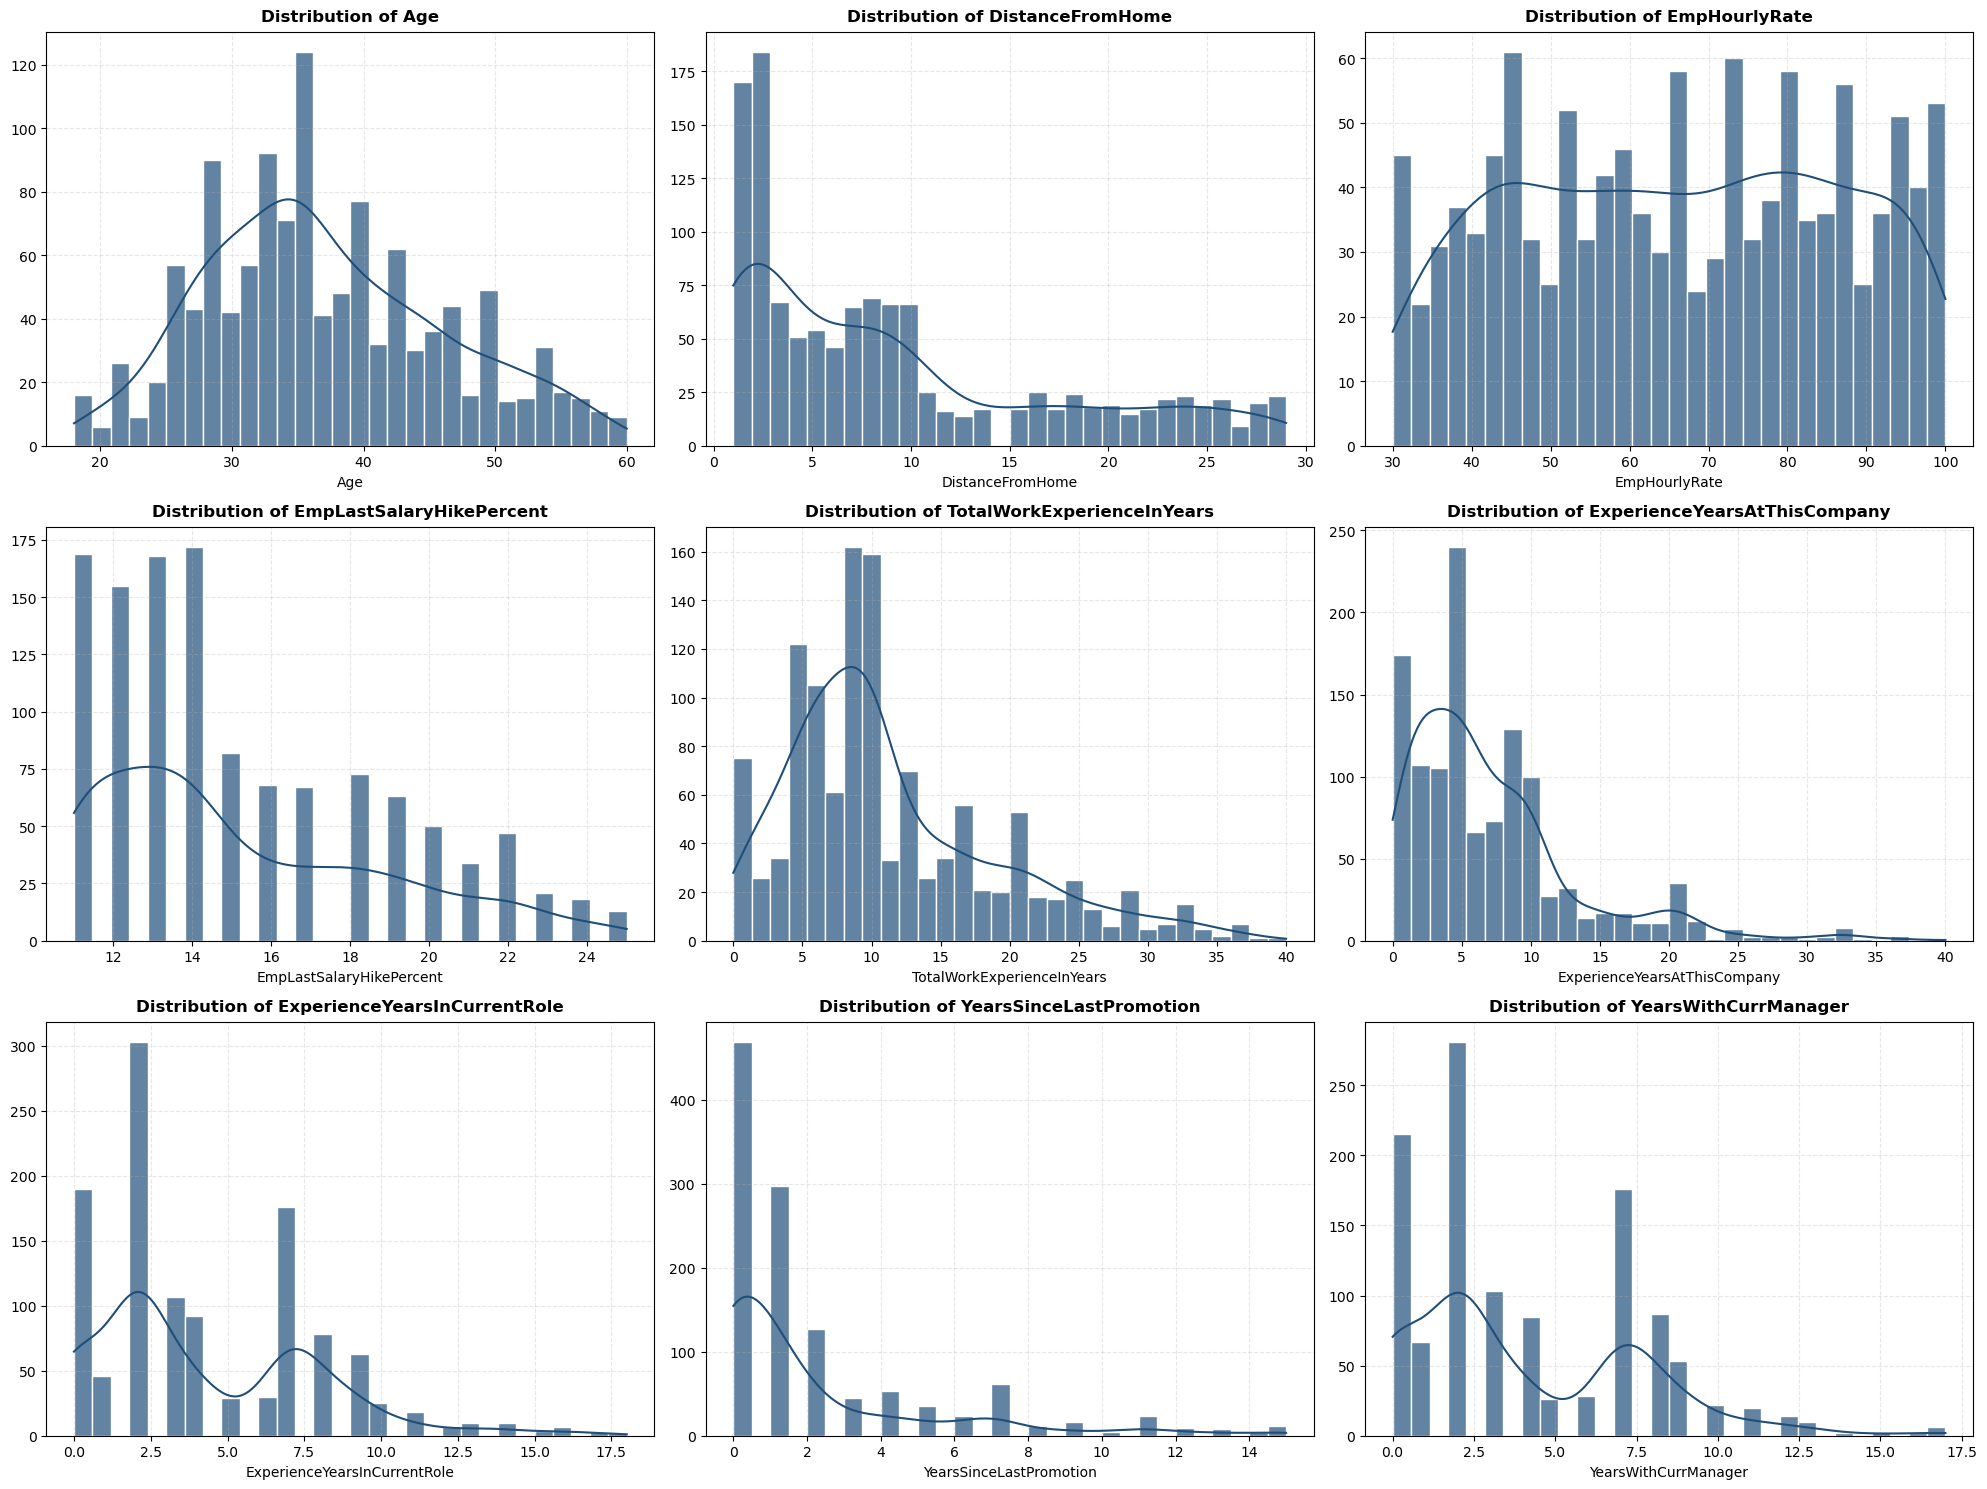

In [11]:
# Set figure size to clearly display multiple distribution plots
plt.figure(figsize=(20, 15))  

# List of continuous numerical features for distribution analysis
continuous_cols = ["Age", "DistanceFromHome", "EmpHourlyRate", "EmpLastSalaryHikePercent", "TotalWorkExperienceInYears", "ExperienceYearsAtThisCompany", 
                    "ExperienceYearsInCurrentRole", "YearsSinceLastPromotion", "YearsWithCurrManager"] 

# Iterate through each feature and plot its distribution
for i, col in enumerate(continuous_cols, 1):
    plt.subplot(3, 3, i)   # Create a 3x3 grid layout for visualization

    # Plot histogram with KDE curve to examine distribution shape and skewness
    sns.histplot(
        data[col],
        kde=True,
        bins=30,
        color="#1f4e79",
        edgecolor="white",
        alpha=0.7
    )

    # Add title for clarity
    plt.title(f"Distribution of {col}", fontsize=12, fontweight="bold", pad=8)
    plt.ylabel("")              
    plt.grid(True, linestyle="--", alpha=0.3)

# Adjust layout to prevent overlapping of plots
plt.tight_layout() 
plt.show() 

### Univariate Analysis – Continuous Variables Interpretations 

#### Distribution of Age

The age distribution appears roughly bell-shaped with a slight right skew. Most employees fall within the 25 to 45-year range, with the highest concentration around the early to mid-30s. There are fewer employees at the extreme younger and older ends of the spectrum.

This suggests that the organization primarily consists of mid-career professionals, which may indicate a stable and experienced workforce rather than a heavily junior or senior-dominated structure.


---

#### Distribution of Distance From Home

Distance from home shows a clear right-skewed distribution. A large proportion of employees live within 1 to 10 kilometers from the workplace, with the highest concentration around shorter distances. As commuting distance increases, the number of employees gradually declines.

This indicates that most employees reside relatively close to the workplace, which may contribute to better attendance, lower commute-related stress, and potentially improved work-life balance.


---

#### Distribution of EmpHourlyRate

Hourly rate appears fairly evenly distributed across the range of approximately 30 to 100. There is no strong central peak or extreme skewness, suggesting that compensation levels are spread across different pay bands rather than concentrated in a narrow range.

This reflects a balanced compensation structure where employees are distributed across various pay levels depending on their role, experience, and responsibilities.


---

#### Distribution of EmpLastSalaryHikePercent

Salary hike percentage is moderately right-skewed, with most employees receiving increments between 11% and 16%. The highest concentration lies around 12% to 14%, while progressively fewer employees receive hikes above 18%.

This suggests that the organization follows a structured and standardized increment policy for most employees, with higher increments being selective and likely performance-driven.


---

#### Distribution of TotalWorkExperienceInYears

Total work experience shows a right-skewed distribution, with most employees having between 5 and 12 years of experience. The peak concentration appears around 7 to 10 years, while fewer employees exceed 20 years of experience.

This indicates that the workforce is largely composed of mid-level professionals rather than highly senior employees, reflecting a dynamic but moderately experienced talent base.


---

#### Distribution of ExperienceYearsAtThisCompany

Years of experience within the company is strongly right-skewed. A significant number of employees have between 2 and 6 years of tenure, with relatively fewer employees staying beyond 15 years.

This suggests moderate employee retention, with a mix of relatively new and moderately experienced employees, rather than a workforce dominated by long-term veterans.


---

#### Distribution of ExperienceYearsInCurrentRole

Experience in the current role is concentrated between 1 and 5 years, with a steady decline beyond that range. Very few employees remain in the same role for extended periods above 10 years.

This pattern indicates internal mobility or periodic role transitions within the organization, suggesting that employees may be promoted or reassigned rather than remaining stagnant.


---

#### Distribution of YearsSinceLastPromotion

Years since last promotion is highly right-skewed, with a large number of employees having been promoted within the last 0 to 2 years. The frequency declines significantly beyond 3 years.

This suggests relatively active promotion cycles within the organization, although a smaller segment of employees may experience longer gaps between promotions.


---

#### Distribution of YearsWithCurrManager

Years with the current manager is moderately right-skewed. Most employees have worked under their current manager for 1 to 5 years, with fewer long-standing reporting relationships.

This indicates some level of managerial rotation or team restructuring, which may reflect organizational flexibility and evolving team dynamics.


---

#### Overall Workforce Profile Insight

Across the continuous variables, the organization appears to consist largely of mid-career professionals with moderate tenure and structured compensation growth. Most employees are neither extremely new nor highly senior, suggesting a stable yet evolving workforce. The patterns indicate a company that emphasizes balanced growth, periodic promotions, and a structured increment system rather than extreme disparities in tenure or compensation. 

#### 2. For Categorical/Discrete Columns: 

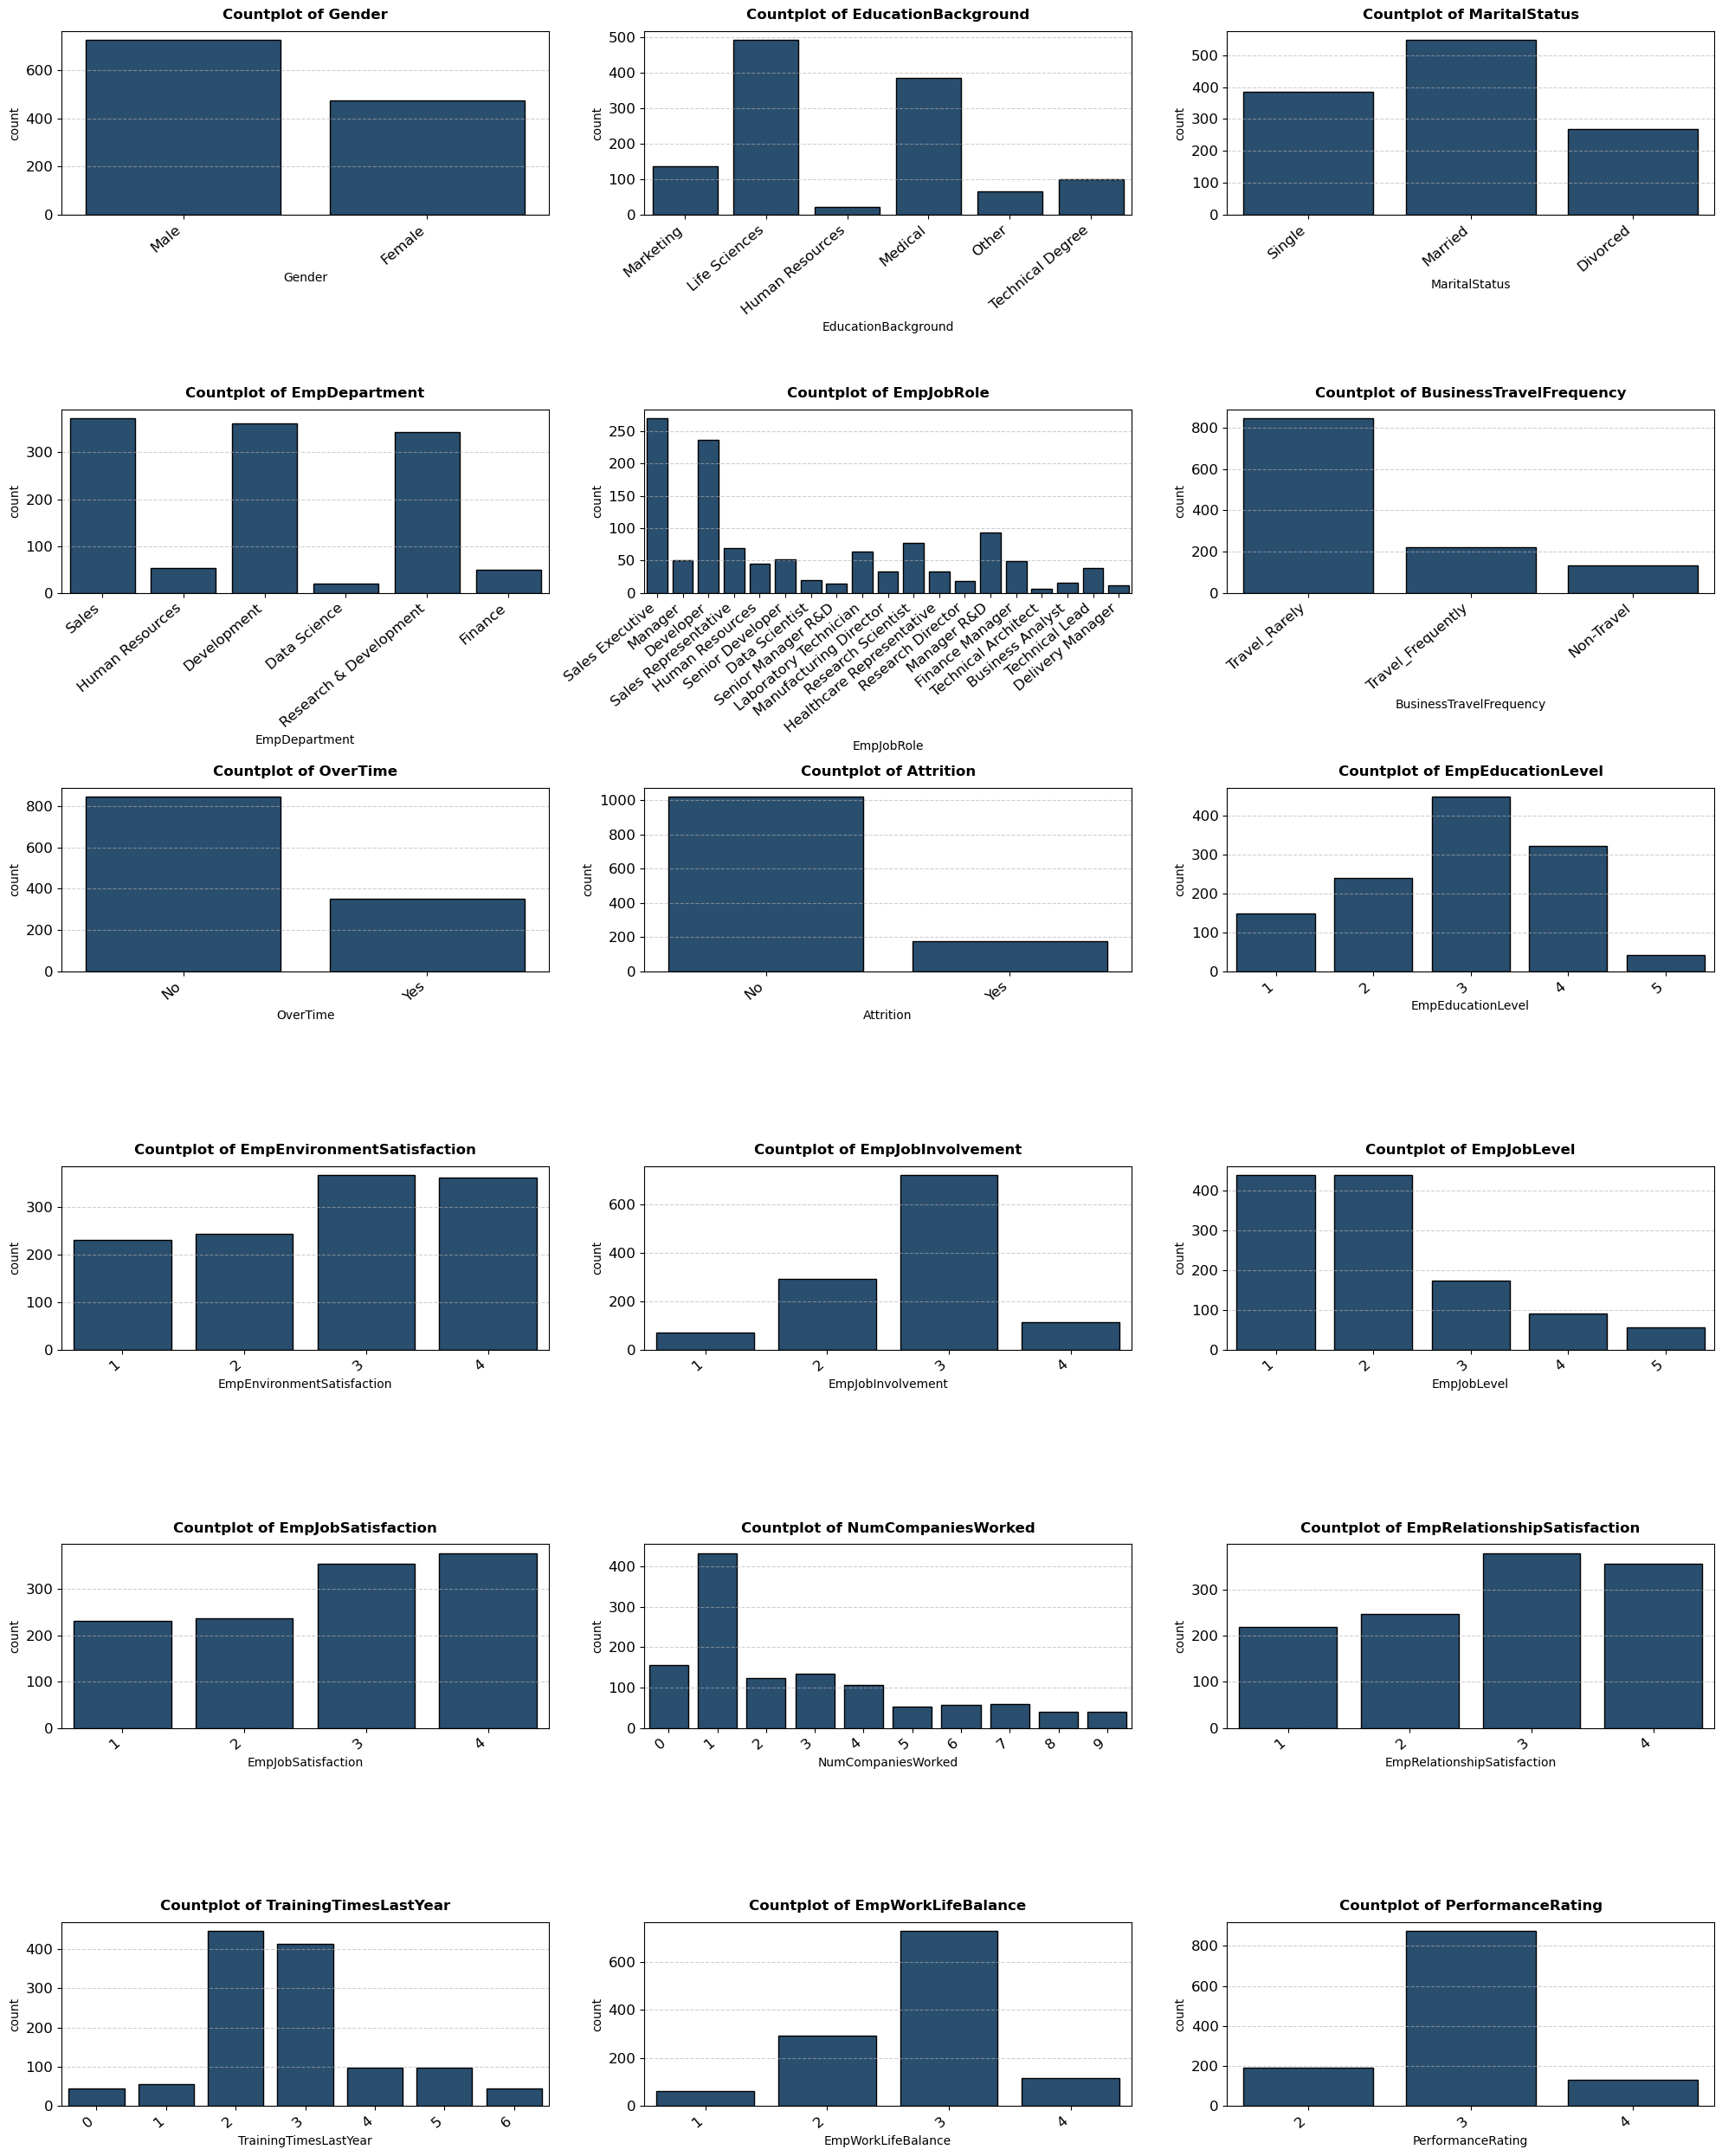

In [12]:
# Set figure size to properly visualize multiple categorical distributions
plt.figure(figsize = (20, 25))  

# Categorical features selected to analyze employee demographics,
# job characteristics, satisfaction levels, and performance distribution
countplot_cols = ["Gender", "EducationBackground", "MaritalStatus", "EmpDepartment", "EmpJobRole", "BusinessTravelFrequency", "OverTime", "Attrition", 
                  "EmpEducationLevel", "EmpEnvironmentSatisfaction", "EmpJobInvolvement", "EmpJobLevel", "EmpJobSatisfaction", "NumCompaniesWorked", 
                  "EmpRelationshipSatisfaction", "TrainingTimesLastYear", "EmpWorkLifeBalance", "PerformanceRating"] 


# Iterate through each categorical feature to examine its distribution
for i, col in enumerate(countplot_cols, 1):
    plt.subplot(6, 3, i) 

    # Countplot to visualize frequency of each category
    sns.countplot(x = data[col], edgecolor = "black", color="#1f4e79")  
    
    # Add title for clear identification of each variable
    plt.title(f"Countplot of {col}", fontsize = 12, fontweight = "bold", pad = 10) 

    # Rotate x-axis labels for better readability (especially for long category names)
    plt.xticks(rotation=40, ha="right", fontsize=12)  

    # Keep y-axis labels clean and readable
    plt.yticks(rotation=0, fontsize=12)                
    
    # Add horizontal gridlines to improve visual comparison of category counts
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6)

    # Adjust layout to prevent subplot overlapping
    plt.tight_layout() 

# Display all categorical distribution plots
plt.show() 

### Univariate Analysis – Categorical & Discrete Variables Interpretation 

### Gender Distribution

The workforce consists of a higher proportion of male employees compared to female employees. Although both genders are represented, the organization appears moderately male-dominated. This may reflect industry-specific hiring trends or historical workforce patterns. From a business perspective, this distribution highlights the current gender composition and may provide insight into diversity considerations within the organization.


---

#### Education Background Distribution

A significant portion of employees come from Life Sciences and Medical backgrounds, with Life Sciences being the most dominant. Marketing and Technical Degree holders form moderate segments, while Human Resources and other backgrounds are relatively smaller.

This suggests that the organization’s core operations are strongly aligned with domain-specific expertise, particularly in life sciences and medical fields. The distribution reflects a workforce structured around specialized knowledge rather than purely administrative or support functions.


---

#### Marital Status Distribution

Most employees are married, followed by single employees, with divorced employees forming the smallest group. This indicates that a large portion of the workforce may be in a relatively stable life stage.

From a business standpoint, this could influence policies related to work-life balance, flexibility, and employee benefits, as family responsibilities often impact work expectations and preferences.


---

#### Department Distribution

The majority of employees are concentrated in Sales, Development, and Research & Development departments. In contrast, departments such as Human Resources, Finance, and Data Science have smaller representation.

This suggests that the organization’s structure is strongly focused on revenue generation and product development, with support functions maintained at leaner levels. The workforce distribution reflects a growth-driven and operationally focused business model.


---

#### Job Role Distribution

Sales Executive and Developer roles form the largest segments of the workforce. Several specialized technical and research roles are present but distributed across smaller counts. Managerial roles exist in lower numbers compared to execution-level positions.

This indicates a pyramid-like structure where frontline and operational roles dominate, supported by a smaller managerial and leadership layer. The organization appears execution-driven, with emphasis on sales and development activities.


---

#### Business Travel Frequency Distribution

A large majority of employees travel rarely, while smaller portions travel frequently or do not travel at all. This suggests that business travel is not a universal requirement but is likely role-specific, possibly concentrated in sales or client-facing positions.

The distribution indicates that most employees operate in relatively stable, location-based roles.


---

#### OverTime Distribution

Most employees do not work overtime, although a noticeable portion does. This suggests that overtime is not widespread across the organization but may be linked to specific roles or departments.

The presence of overtime cases may have implications for workload management and employee well-being.


---

#### Attrition Distribution

The majority of employees have not left the organization, with a smaller proportion representing attrition cases. This indicates overall workforce stability.

However, even a smaller attrition segment can have strategic impact depending on which roles or departments are affected.


---

#### Employee Education Level Distribution

Most employees fall within education levels 2, 3, and 4, with level 3 being the most common. Very few employees are at the highest level.

This suggests that the organization primarily employs moderately to highly educated professionals, maintaining a balanced qualification structure rather than extreme concentration at very high academic levels.


---

#### Employee Environment Satisfaction Distribution

Employee environment satisfaction appears generally positive, with higher concentrations in levels 3 and 4. Lower satisfaction levels are present but not dominant.

This indicates that most employees perceive their work environment favorably, though there remains scope for improvement among those reporting lower satisfaction.


---

#### Employee Job Involvement Distribution

Job involvement is largely concentrated at level 3, suggesting moderate engagement across the workforce. Very few employees fall into the lowest involvement category.

This indicates a reasonably engaged workforce, though the relatively smaller proportion at the highest involvement level suggests potential room for deeper engagement initiatives.


---


#### Employee Job Satisfaction Distribution

Job satisfaction levels are generally higher, with most employees falling in levels 3 and 4. Lower satisfaction levels are present but not dominant.

This suggests that overall employee sentiment toward their job role is positive, though monitoring lower satisfaction groups remains important.


---

#### Number of Companies Worked Distribution

Most employees have worked in 1 to 3 companies, with a sharp decline as the number increases. Very few employees have worked in many different organizations.

This suggests moderate career mobility among employees, with many having some prior experience but not excessive job switching.


---

#### Employee Relationship Satisfaction Distribution

Relationship satisfaction levels are concentrated in levels 3 and 4, indicating generally positive workplace relationships. Lower satisfaction levels are present but comparatively smaller.

This suggests that most employees maintain healthy professional relationships within the organization.


---

#### Training Times Last Year Distribution

Most employees received 2 to 3 training sessions in the last year, while very few had none or very high numbers.

This indicates structured and fairly consistent training practices across the organization, reflecting investment in employee development.


---

#### Work-Life Balance Distribution

The majority of employees report work-life balance at level 3, followed by level 2 and 4. Very few employees report extremely poor balance.

This suggests a moderately balanced work environment overall, though some improvement may be possible to move more employees toward higher satisfaction levels.


---

#### Performance Rating Distribution

Most employees fall under performance rating 3, with significantly fewer employees in ratings 2 and 4.

This suggests that the organization tends to cluster employees in the “good” performance category, with fewer employees categorized as either underperforming or exceptional. 

### Bivariate Analysis 

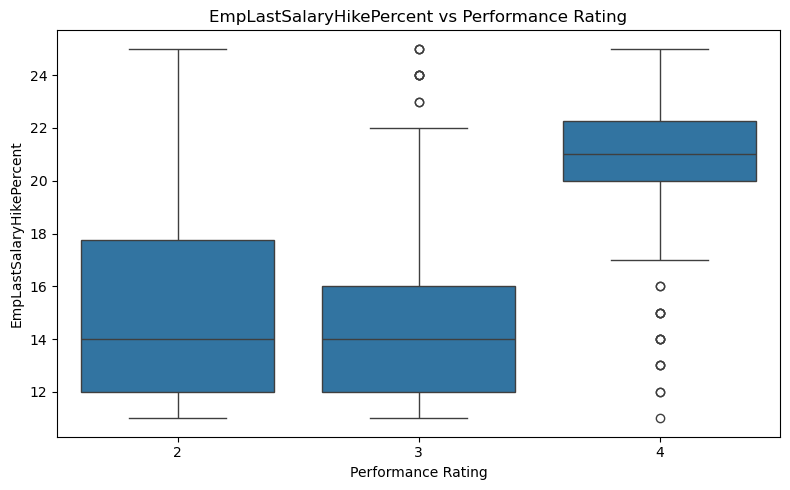

In [13]:
# ===============================
# Salary Hike vs Performance
# =============================== 

# Compare salary hike percentage across different performance ratings
plt.figure(figsize=(8,5))

sns.boxplot(x='PerformanceRating', y='EmpLastSalaryHikePercent', data=data)

# Add descriptive title and axis labels for clarity
plt.title("EmpLastSalaryHikePercent vs Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("EmpLastSalaryHikePercent")

# Adjust layout for better spacing
plt.tight_layout()
plt.show() 

This variable shows a noticeable difference compared to the others.

The median salary hike for ratings 2 and 3 is around 14%, and their distributions overlap heavily. However, rating 4 shows a clear upward shift, with a median around 21%, and most of its interquartile range lies above 20%.

This indicates that employees rated as excellent (rating 4) receive significantly higher salary hikes compared to average or good performers. While ratings 2 and 3 are not strongly differentiated in terms of hike percentage, rating 4 stands out clearly.

This suggests a strong positive association between salary hike percentage and top-level performance. 

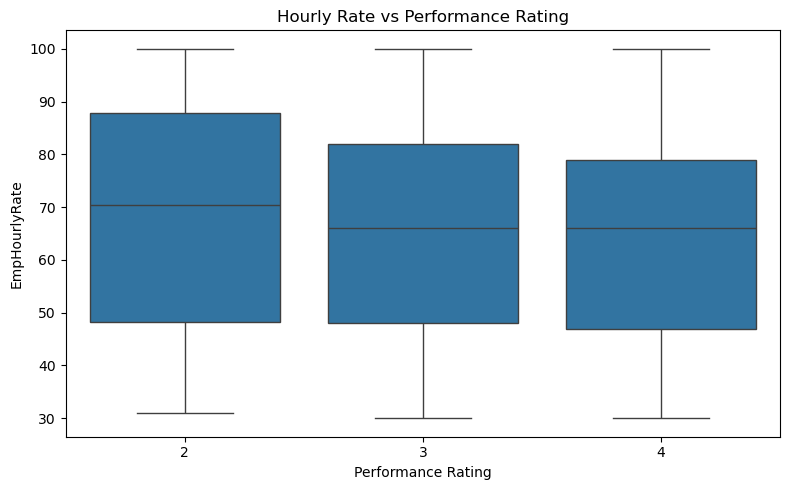

In [14]:
# ===============================
# Hourly Wage vs Performance
# ===============================

# Analyze distribution of hourly wage across performance rating categories
plt.figure(figsize=(8,5))

sns.boxplot(x='PerformanceRating', y='EmpHourlyRate', data=data)

# Add descriptive title and axis labels for clarity
plt.title("Hourly Rate vs Performance Rating")
plt.xlabel("Performance Rating")
plt.ylabel("EmpHourlyRate")

# Adjust layout for better visualization
plt.tight_layout()
plt.show() 

The distribution of hourly rate across performance categories shows substantial overlap. The medians for ratings 2, 3, and 4 are very similar, and there is no clear increasing or decreasing pattern as performance rating changes.

This indicates that base hourly compensation alone does not strongly differentiate performance levels. Employees receiving higher hourly rates are not necessarily those receiving higher performance ratings. 

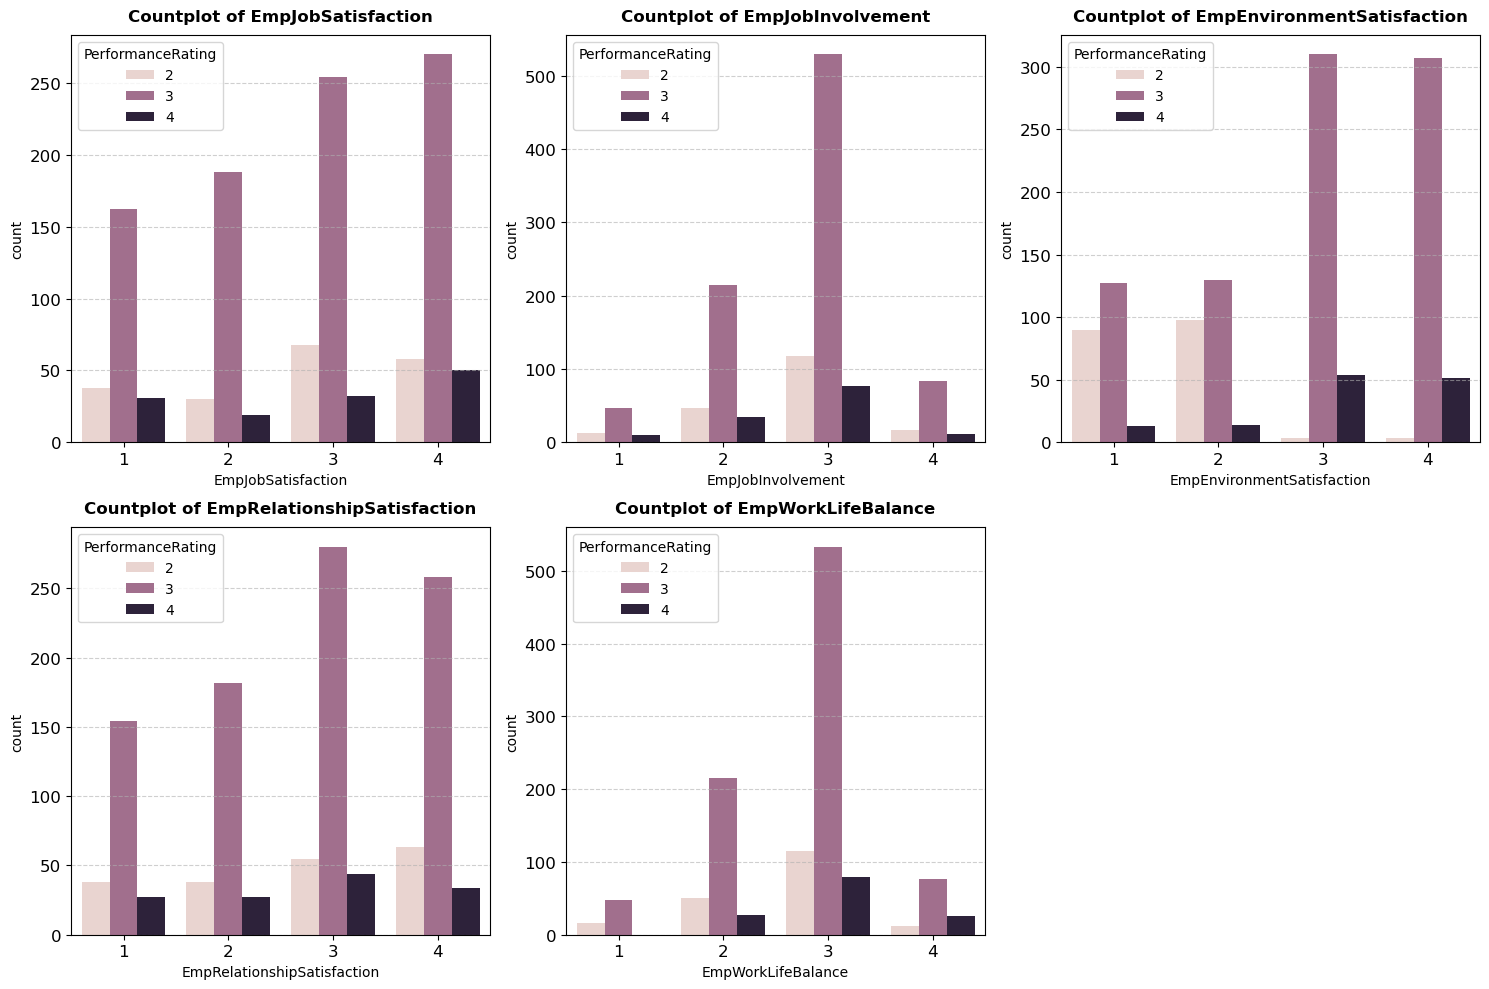

In [15]:
# ===============================
# Engagement & Satisfaction Factors
# ===============================

# Set figure size to clearly display multiple engagement-related plots
plt.figure(figsize = (15, 10))  

# Engagement and satisfaction variables to analyze their relationship with performance
engagement_vars = ['EmpJobSatisfaction', 'EmpJobInvolvement', 'EmpEnvironmentSatisfaction', 'EmpRelationshipSatisfaction', 'EmpWorkLifeBalance'] 


# Iterate through each engagement variable to compare distribution across performance levels
for i, col in enumerate(engagement_vars, 1):
    plt.subplot(2, 3, i)  

    # Countplot to visualize how satisfaction/involvement levels vary by performance rating
    sns.countplot(x = data[col], hue = data["PerformanceRating"]) 
    
    # Add title for clear interpretation of each comparison
    plt.title(f"Countplot of {col}", fontsize = 12, fontweight = "bold", pad = 10) 

    # Format x-axis labels for readability
    plt.xticks(fontsize=12)  

    # Keep y-axis labels clean and readable
    plt.yticks(fontsize=12)                
    
    # Add horizontal gridlines to improve visual comparison
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6)

    # Adjust layout to prevent overlapping
    plt.tight_layout() 

# Display the plots
plt.show() 

### Engagement & Satisfaction Factors vs Performance Rating  

#### EmpJobSatisfaction vs PerformanceRating  

Performance rating 3 dominates across all satisfaction levels, which aligns with the overall distribution of ratings in the dataset. However, employees with higher job satisfaction levels (3 and 4) show relatively more high performers (rating 4) compared to satisfaction levels 1 and 2.  

The increase is gradual rather than sharp, indicating that job satisfaction positively supports performance but is not the sole determining factor.

---

#### EmpJobInvolvement vs PerformanceRating  

Job involvement shows a clearer pattern. Employees with low involvement (level 1) have very few high performers. As involvement increases from level 1 to level 3, the number of high performers increases steadily.  

Although involvement level 4 shows slightly lower counts, this is likely due to fewer employees in that category. Overall, higher job involvement appears more strongly associated with better performance.

---

#### EmpEnvironmentSatisfaction vs PerformanceRating  

Employees with lower environment satisfaction (levels 1 and 2) tend to have fewer high-performance ratings. As satisfaction increases to levels 3 and 4, the presence of high performers increases.  

The difference between levels 3 and 4 is not drastic, suggesting that once a comfortable work environment is achieved, additional improvements may not significantly elevate performance further.

---

#### EmpRelationshipSatisfaction vs PerformanceRating  

A gradual improvement in performance is visible as relationship satisfaction increases. Higher satisfaction levels (3 and 4) show relatively more high performers compared to lower levels.  

However, performance rating 3 remains dominant across all levels, indicating that workplace relationships contribute to performance but do not independently drive it.

---

#### EmpWorkLifeBalance vs PerformanceRating  

Work-life balance shows a noticeable pattern. Employees reporting balance level 3 have the highest representation of high performers. Very low balance (level 1) corresponds with minimal high-performance ratings.  

Performance does not continuously increase beyond level 3, suggesting that moderate balance may be optimal. Beyond a certain point, the performance benefit appears to stabilize.

---

#### Overall Insight  

Across all engagement and satisfaction factors:  

- Performance rating 3 remains dominant.  
- Higher satisfaction and involvement levels show relatively more high performers.  
- The relationships are positive but moderate.  

This indicates that engagement-related factors support better performance, but they likely work in combination with compensation, experience, and role-related variables rather than acting as independent drivers. 

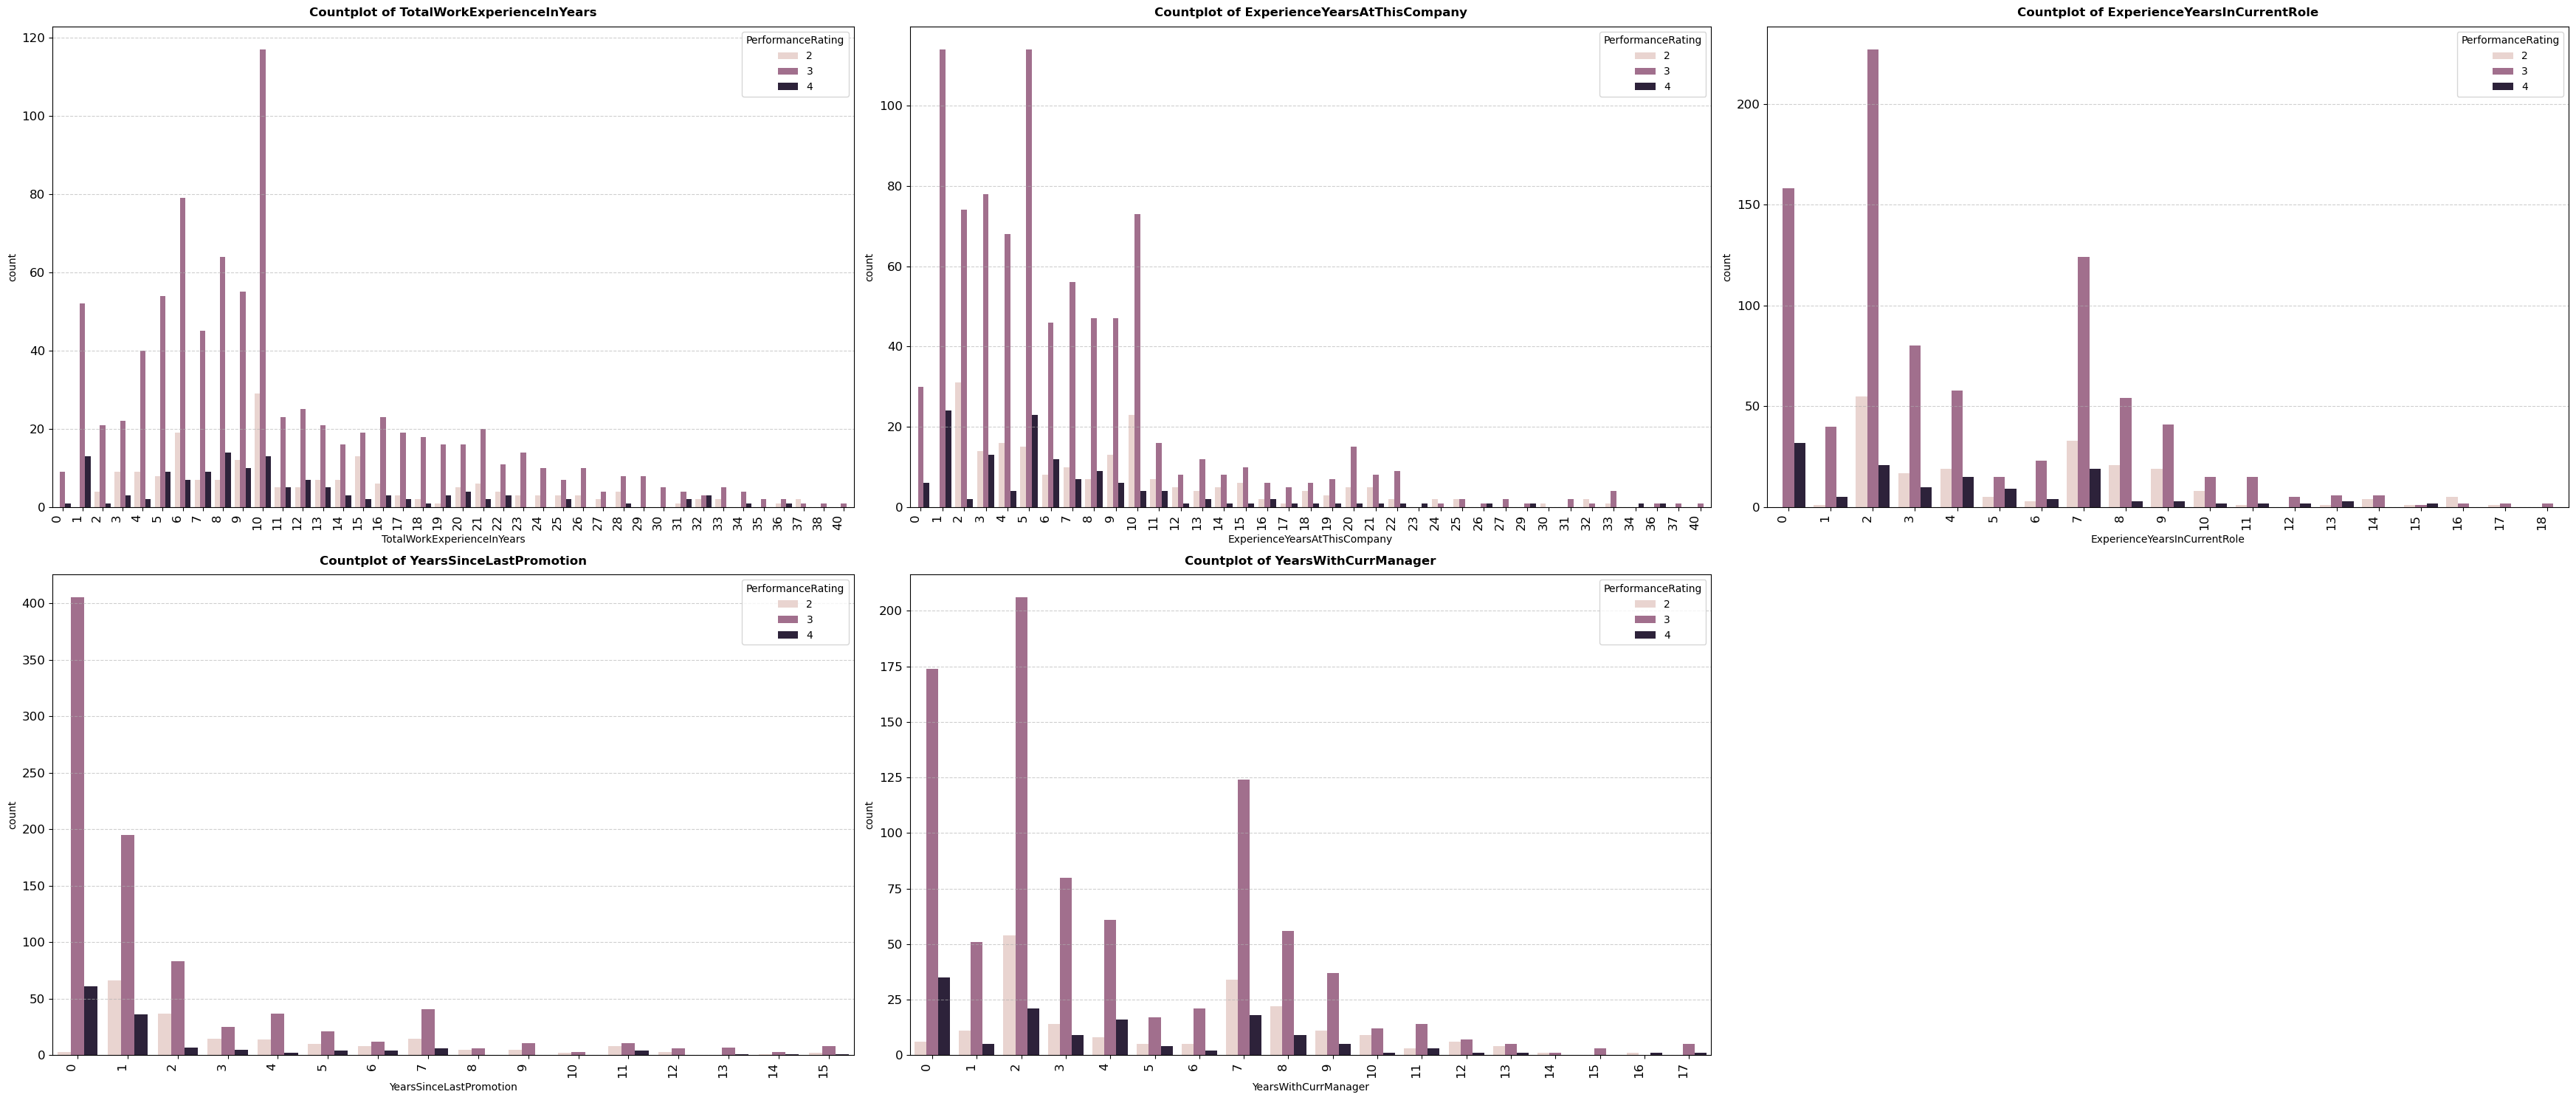

In [16]:
# ===============================
# Experience & Tenure Factors
# =============================== 

# Set figure size to clearly visualize multiple experience-related plots
plt.figure(figsize = (35, 15))  

# Experience and tenure-related variables to analyze their relationship with performance
experience_vars = ['TotalWorkExperienceInYears', 'ExperienceYearsAtThisCompany', 'ExperienceYearsInCurrentRole', 'YearsSinceLastPromotion', 
                   'YearsWithCurrManager']

# Iterate through each experience variable to compare distribution across performance levels
for i, col in enumerate(experience_vars, 1):
    plt.subplot(2, 3, i)  

    # Countplot to examine how experience levels vary by performance rating
    sns.countplot(x = data[col], hue = data["PerformanceRating"]) 
    
    # Add title for clear interpretation
    plt.title(f"Countplot of {col}", fontsize = 12, fontweight = "bold", pad = 10) 

    # Rotate x-axis labels for better readability (many unique values)
    plt.xticks(rotation=90, ha="right", fontsize=12)  

    # Keep y-axis labels clean
    plt.yticks(rotation=0, fontsize=12)                
    
    # Add horizontal gridlines to improve comparison
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6)

    # Adjust layout to prevent overlapping
    plt.tight_layout() 

# Display the plots
plt.show() 

### Experience & Tenure Factors vs Performance Rating  

#### TotalWorkExperienceInYears vs PerformanceRating  

Most employees fall between 2 to 10 years of total work experience, and within this range, performance rating 3 clearly dominates.  

High performers (rating 4) are present across early and mid-career stages, especially around 5–10 years of experience. However, there is no strong linear pattern showing that performance keeps increasing with more total experience.  

After around 15+ years, the counts drop significantly (naturally, because fewer employees are in that range), and high performers also become rare.  

**Business insight:**  
Experience helps to an extent, but simply having more years in the industry does not automatically translate into higher performance. Performance seems more concentrated in the early to mid-career stage rather than very senior experience levels.

---

#### ExperienceYearsAtThisCompany vs PerformanceRating  

Most employees have 0–5 years of tenure in the company. Performance rating 3 dominates across all tenure levels.  

High performers (rating 4) are visible particularly around 2–6 years at the company. After very long tenure (10+ years), the counts reduce and high performers become less frequent.  

**Business insight:**  
Employees tend to perform strongly during their growth phase in the company (early to mid tenure). Very long tenure does not necessarily show proportionally higher performance. This may suggest that performance peaks during active growth years rather than during stagnation.

---

#### ExperienceYearsInCurrentRole vs PerformanceRating  

The highest counts are concentrated between 1–4 years in the current role. High performers are also visible mainly in this range.  

After around 7–8 years in the same role, both overall counts and high performers reduce significantly.  

**Business insight:**  
Spending a moderate amount of time in a role seems beneficial. However, very long duration in the same role may not strongly correlate with higher performance. This could indicate the importance of role progression and career movement to sustain performance levels.

---

#### YearsSinceLastPromotion vs PerformanceRating  

A very large portion of employees have 0–2 years since their last promotion. High performers are clearly more visible in the 0–1 year range.  

As the number of years since last promotion increases, the number of high performers decreases significantly.  

**Business insight:**  
Recent promotion appears positively associated with performance. Employees who were promoted recently are more likely to be high performers. On the other hand, employees who have not been promoted for many years show fewer high ratings, which may reflect stagnation or reduced recognition.

---

#### YearsWithCurrManager vs PerformanceRating  

Most employees have worked with their current manager for 0–3 years. High performers are present mainly within this range.  

As years with the same manager increase beyond 6–7 years, both overall counts and high performers decline.  

**Business insight:**  
A moderate duration with a manager may support stable performance. However, very long periods under the same reporting structure do not show a strong rise in high performance. This might suggest that managerial refresh or role changes could influence performance positively.

---

#### Overall Experience-Related Insight  

Across all tenure and experience variables:  

- Performance rating 3 dominates overall.  
- High performers are mostly concentrated in early-to-mid career stages.  
- Extremely high tenure or very long time in the same role does not show a strong increase in performance.  
- Recent promotions appear more strongly linked to high performance compared to raw years of experience.

Overall, performance seems more connected to career progression and engagement phase rather than just total years worked. 

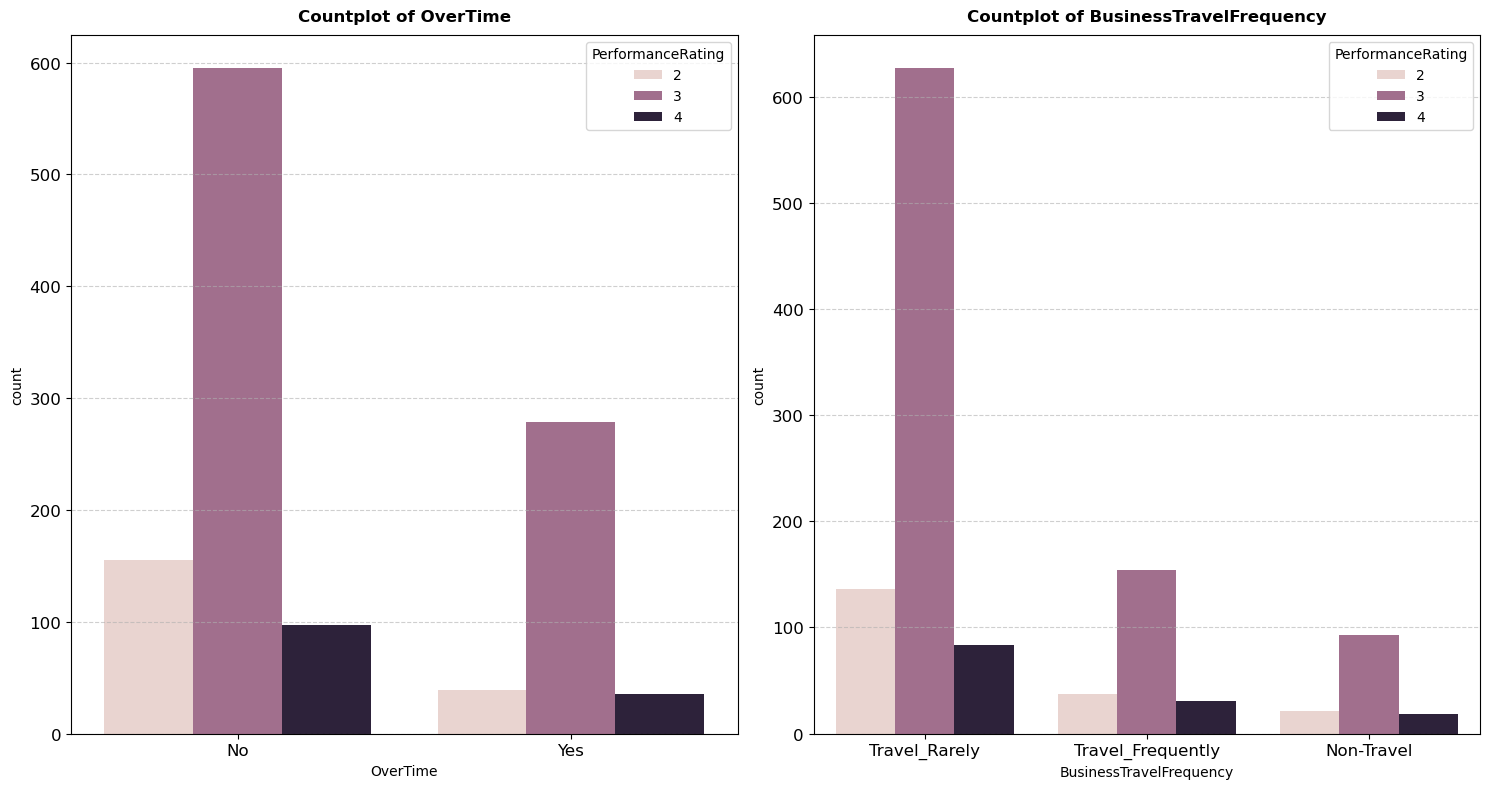

In [17]:
# ===============================
# Workload & Travel Factors
# =============================== 

# Set figure size to clearly visualize workload-related categorical variables
plt.figure(figsize = (15, 8))  

# Workload and travel-related variables to analyze their relationship with performance
workload_vars = ['OverTime', 'BusinessTravelFrequency'] 

# Iterate through each variable to compare category distribution across performance ratings
for i, col in enumerate(workload_vars, 1):
    plt.subplot(1, 2, i)  

    # Countplot to examine how workload/travel frequency varies by performance level
    sns.countplot(x = data[col], hue = data["PerformanceRating"]) 
    
    # Add title for clear interpretation
    plt.title(f"Countplot of {col}", fontsize = 12, fontweight = "bold", pad = 10) 

    # Format axis labels for readability
    plt.xticks(fontsize=12)  
    plt.yticks(fontsize=12)                
    
    # Add horizontal gridlines to improve visual comparison
    plt.grid(axis = "y", linestyle = "--", alpha = 0.6)

    # Adjust layout to prevent overlapping
    plt.tight_layout() 

# Display the plots
plt.show() 

### Work Pattern Factors vs Performance Rating  

#### OverTime vs PerformanceRating  

A large portion of employees do not work overtime, and naturally, most performance ratings (especially rating 3) are concentrated in this group.  

When we look at high performers (rating 4), they are present in both categories — those who work overtime and those who do not. However, the proportion of high performers does not drastically increase in the overtime group.  

In fact, working overtime does not seem to strongly boost performance ratings. The majority of high performers are still among employees who do not work overtime.  

**Business insight:**  
Overtime does not appear to be a strong driver of high performance. This suggests that productivity may be more linked to efficiency and engagement rather than long working hours. Simply increasing work hours may not translate into better performance outcomes.

---

#### BusinessTravelFrequency vs PerformanceRating  

Most employees fall under "Travel_Rarely", and as expected, most ratings are concentrated in this category.  

High performers (rating 4) are visible across all travel categories — Travel_Rarely, Travel_Frequently, and Non-Travel. However, there is no sharp spike in high performance among frequent travelers.  

Frequent travel does not clearly show a performance advantage over rare or no travel.  

**Business insight:**  
Business travel frequency does not show a strong relationship with higher performance ratings. This suggests that travel exposure alone may not significantly influence performance levels. Performance may depend more on role quality, skill level, and engagement rather than travel intensity.

---

#### Overall Insight from Work Pattern Variables  

- Overtime does not strongly correlate with higher performance.
- Frequent business travel does not guarantee higher performance.
- Performance rating 3 remains dominant across all work pattern categories.
- High performance seems distributed across categories rather than concentrated in high-intensity work patterns.

Overall, performance appears to be influenced more by qualitative factors (skills, engagement, progression) rather than workload intensity or travel frequency. 

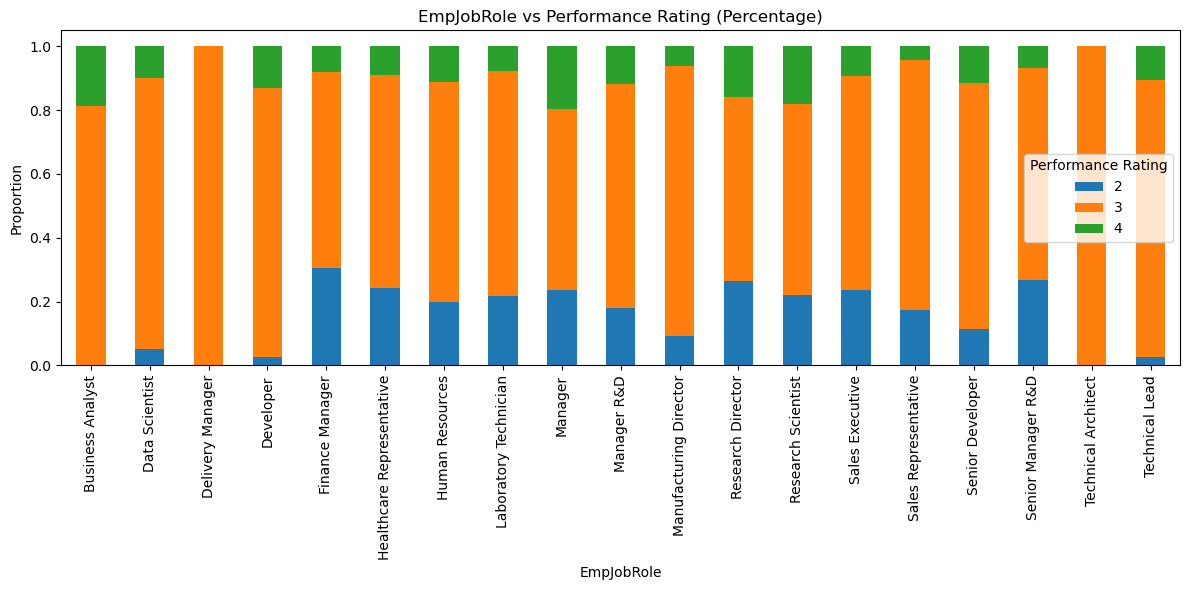

In [18]:
# ===============================
# Job Role vs Performance
# ===============================

# Create a cross-tabulation of job role vs performance rating (row-wise percentage)
role_perf = pd.crosstab(data['EmpJobRole'],
                        data['PerformanceRating'],
                        normalize='index')

# Plot stacked bar chart to compare performance distribution across job roles
role_perf.plot(kind='bar', stacked=True, figsize=(12,6))

# Add title and axis labels for clear interpretation
plt.title("EmpJobRole vs Performance Rating (Percentage)")
plt.xlabel("EmpJobRole")
plt.ylabel("Proportion")
plt.legend(title="Performance Rating")

# Adjust layout to prevent overlap
plt.tight_layout()
plt.show() 

### EmpJobRole vs Performance Rating (Percentage)

This percentage plot helps us compare roles fairly, regardless of how many employees are in each role.

#### Overall Pattern  
Across almost all job roles, **Performance Rating 3 dominates heavily**. In most roles, around 80–90% employees fall under rating 3. This shows that the organization mostly rates employees as “meets expectations,” and extreme ratings (2 or 4) are relatively rare.

#### High Performers (Rating 4)  
R&D-related roles like **Research Scientist, Manager R&D, and Research Director** show a slightly higher proportion of rating 4 compared to many other roles. However, the difference is moderate — not dramatic.

#### Lower Performance (Rating 2)  
Some roles such as **Finance Manager, HR, and Senior Manager R&D** show a slightly higher share of rating 2, but again, the variation is not very large.

#### Business Insight  
Job role alone does not appear to strongly differentiate performance. While some technical/R&D roles show a slightly better share of high performers, overall performance distribution is quite similar across roles. 

### Multivariate Analysis 

#### Checking for Correlation(Correlation Matrix) 

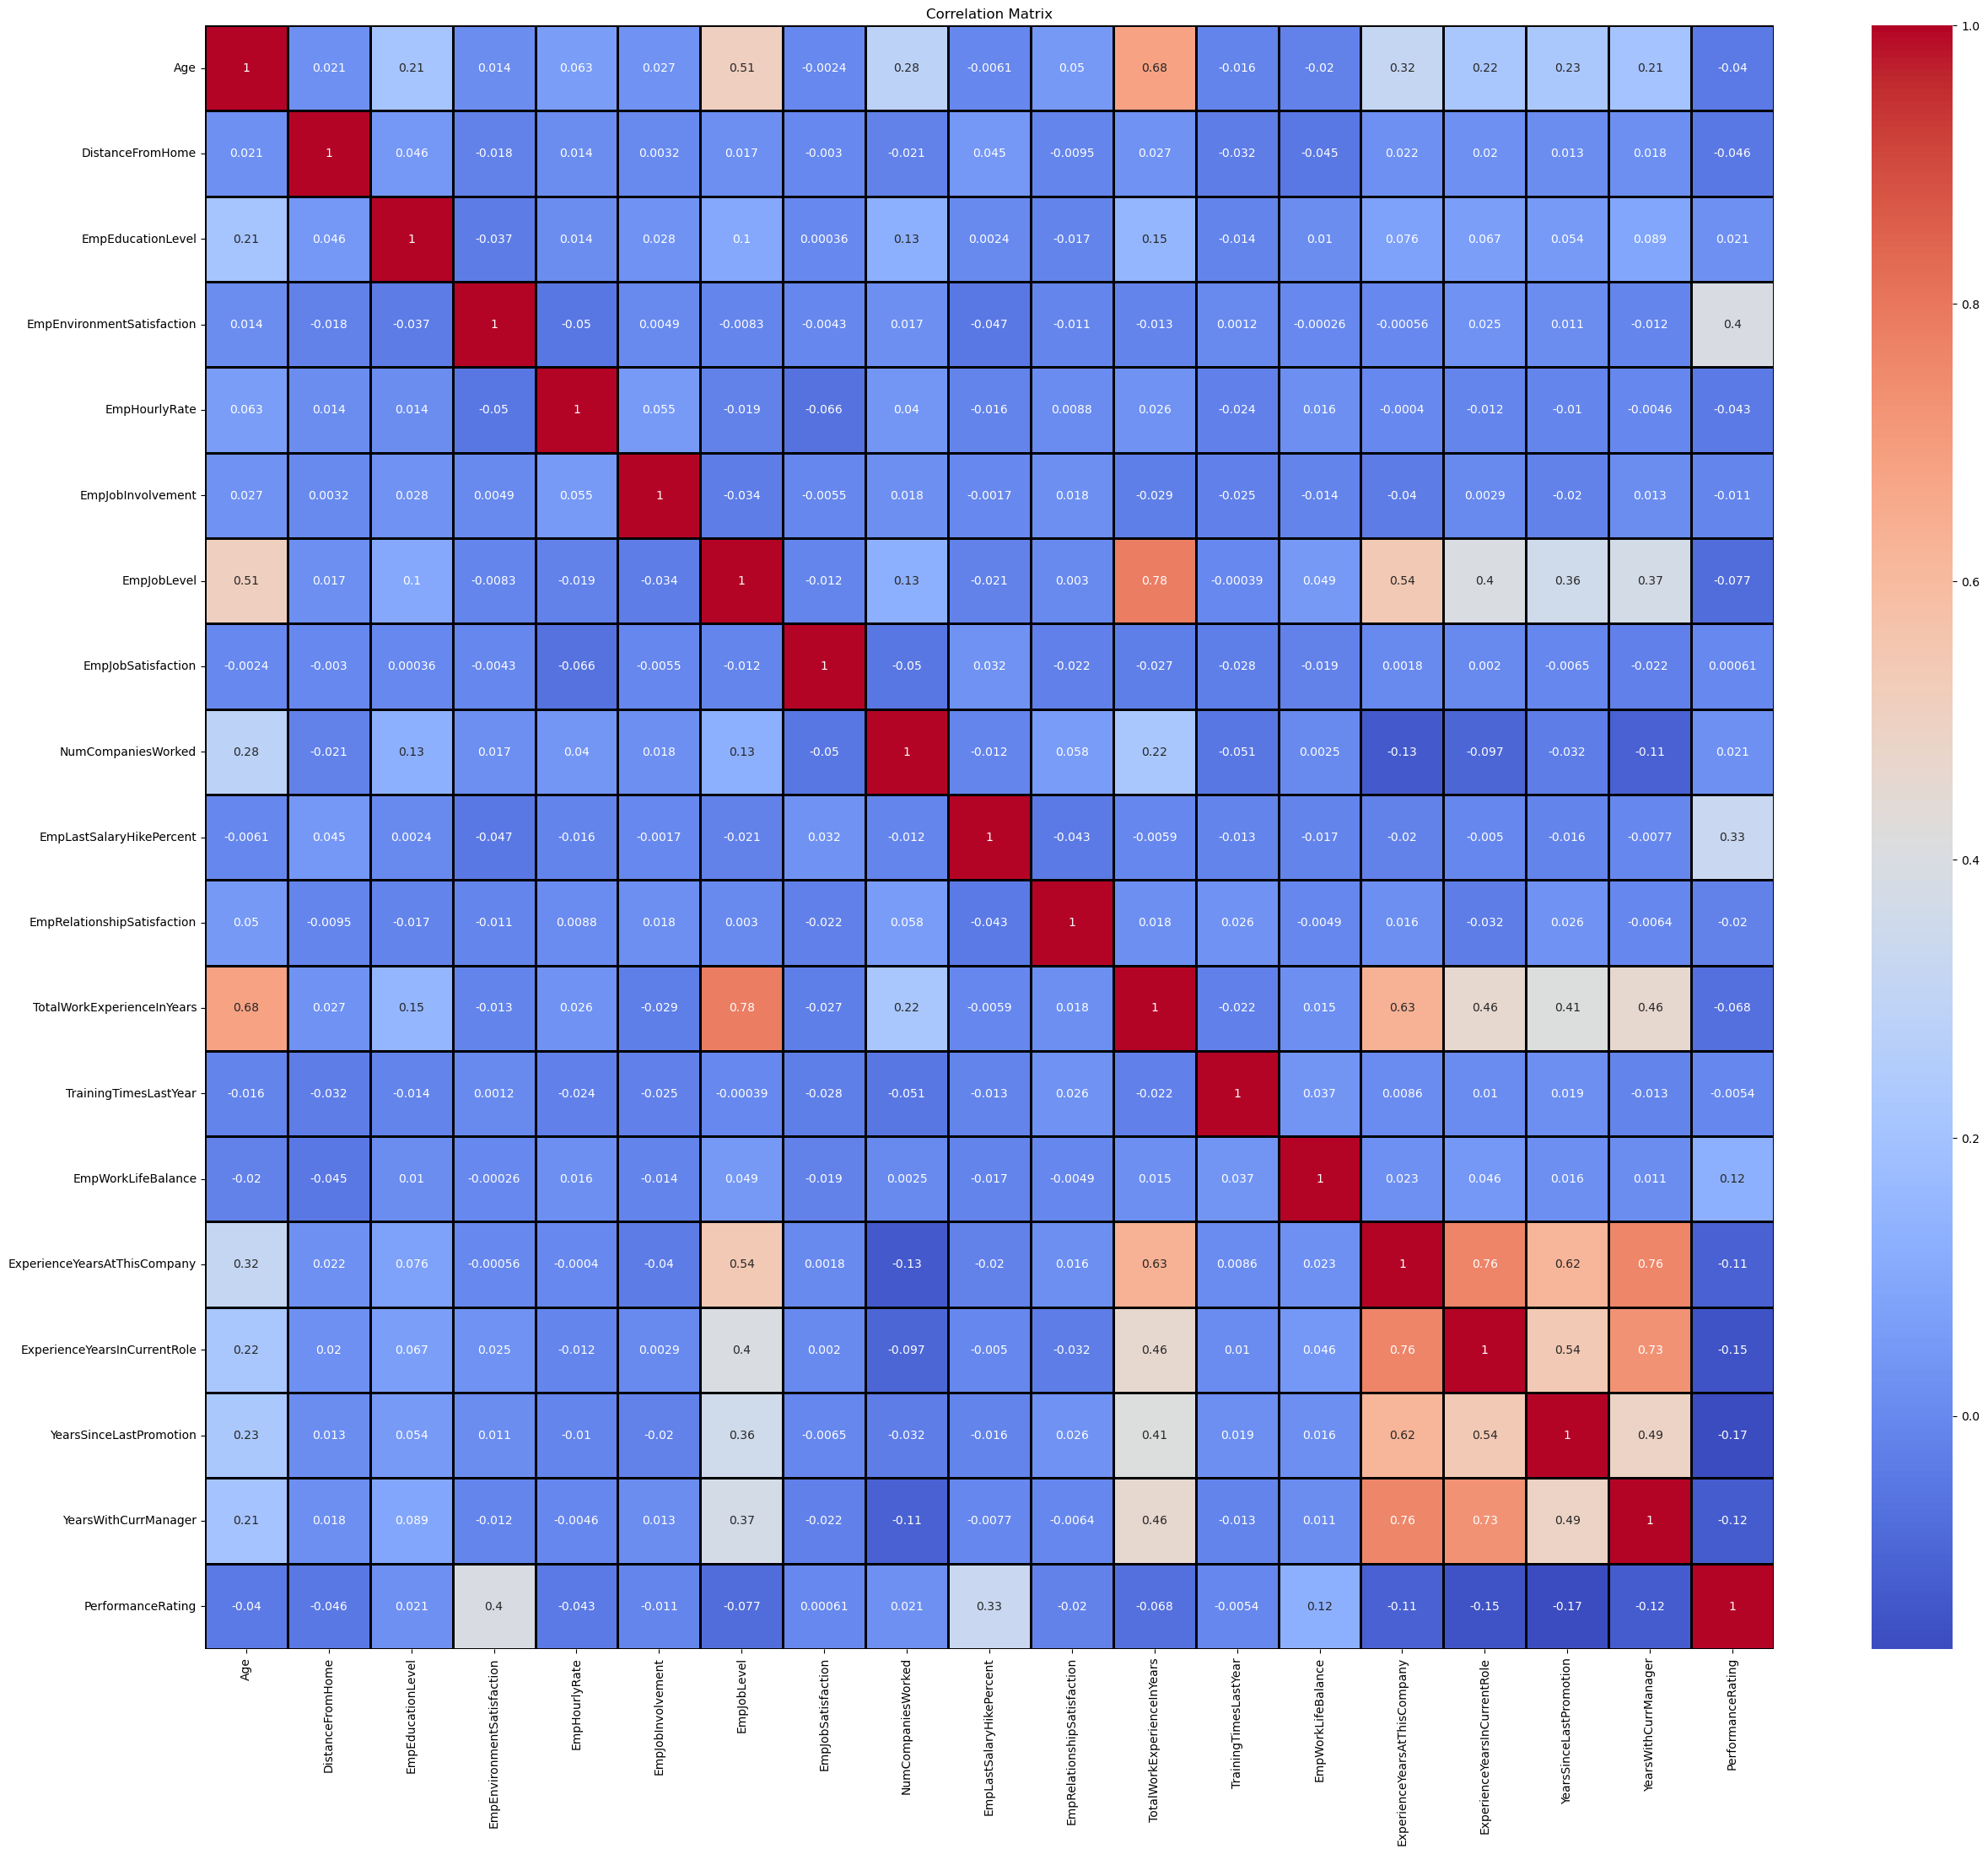

In [19]:
# Set the overall figure size 
plt.figure(figsize=(30, 25)) 

# Select only numerical columns from the dataset for correlation analysis 
numerical_cols = data.select_dtypes(include = ["int", "float"]) 

# Plot a heatmap showing correlations between numerical features 
sns.heatmap(numerical_cols.corr(), annot = True, cmap = "coolwarm", linewidths = 1, linecolor = "black") 

# Add a title to the heatmap 
plt.title("Correlation Matrix") 

plt.show() 

#### Correlation Heatmap – Interpretation

When we focus specifically on **PerformanceRating**, only a few variables show meaningful linear relationships.

#### What positively relates to performance?

The strongest positive correlation is with **EmpEnvironmentSatisfaction (~0.40)**.  
This suggests that employees who are more satisfied with their work environment tend to have better performance ratings. This aligns well with what we observed earlier in the count plots.

Next comes **EmpLastSalaryHikePercent (~0.33)**.  
Employees who received higher salary hikes tend to have higher performance ratings. This makes business sense — better performers are often rewarded with better hikes.

Other variables like **WorkLifeBalance (~0.12)** show only a weak positive relationship.

---

#### What negatively relates to performance?

Some tenure-related variables show slight negative correlations:

- **YearsSinceLastPromotion (~ -0.17)**
- **ExperienceYearsInCurrentRole (~ -0.15)**
- **YearsWithCurrManager (~ -0.12)**

This indicates that employees who have stayed too long without promotion or in the same role tend to have slightly lower performance ratings. It supports the idea that stagnation may reduce performance over time.

However, these relationships are weak to moderate — not very strong.

---

#### Multicollinearity (Important for Modeling)

There are very strong correlations among experience-related variables:

- TotalWorkExperience ↔ EmpJobLevel (0.78)
- ExperienceYearsAtThisCompany ↔ YearsWithCurrManager (0.76)
- ExperienceYearsInCurrentRole ↔ YearsWithCurrManager (0.73)
- Age ↔ TotalWorkExperience (0.68)

This means many of these variables are carrying similar information. For modeling, we should not keep all of them together, as they can create redundancy.

---

#### Overall Conclusion

- Environment satisfaction and salary hike show the strongest linear relationship with performance.
- Long stagnation in role or promotion slightly reduces performance.
- Many experience-related features are highly correlated and will need careful selection before modeling.
- Most other variables show very weak linear relationships, meaning performance is likely influenced by multiple combined factors rather than one single dominant driver. 

### Dropping Unnecessary Columns 

In [20]:
data.drop("Attrition", axis = 1, inplace = True) 

The Attrition variable was dropped as it represents a post-performance outcome and may introduce data leakage. Since the goal is to predict employee performance, attrition would not be available at the time of prediction and therefore was excluded from the feature set. 

## Encoding Categorical Variables 

In [21]:
from sklearn.preprocessing import LabelEncoder # Importing required library/module 

In [22]:
# Initialize LabelEncoder for converting categorical variables into numeric form
label_enc = LabelEncoder() 

# Encode EmpJobRole into numeric labels for modeling
data["EmpJobRole"] = label_enc.fit_transform(data["EmpJobRole"]) 

# Encode OverTime (Yes/No) into numeric format
data["OverTime"] = label_enc.fit_transform(data["OverTime"]) 

# Encode target variable (PerformanceRating) into numeric classes
data["PerformanceRating"] = label_enc.fit_transform(data["PerformanceRating"]) 

In [23]:
# Apply one-hot encoding to categorical features to make them model-ready
data = pd.get_dummies(data, columns = ["Gender", "MaritalStatus", "BusinessTravelFrequency", "EmpDepartment", "EducationBackground"], dtype = int, drop_first = True) 

Label Encoding was applied to **EmpJobRole, OverTime, and PerformanceRating** to convert them into numerical form. In the case of **EmpJobRole**, since it contains 19 unique categories, label encoding was preferred to avoid creating too many dummy columns.

One-Hot Encoding was applied to other categorical variables like **Gender, MaritalStatus, BusinessTravelFrequency, EmpDepartment, and EducationBackground** to ensure the model does not assume any ordinal relationship between categories.

This encoding step prepares the dataset for modeling while controlling dimensionality and preserving meaningful structure. 

## Spliting data into training and testing 

In [24]:
data.head() # Showing first few rows for a quick glance at structure 

,Age,EmpJobRole,DistanceFromHome,EmpEducationLevel,EmpEnvironmentSatisfaction,EmpHourlyRate,EmpJobInvolvement,EmpJobLevel,EmpJobSatisfaction,NumCompaniesWorked,OverTime,EmpLastSalaryHikePercent,EmpRelationshipSatisfaction,TotalWorkExperienceInYears,TrainingTimesLastYear,EmpWorkLifeBalance,ExperienceYearsAtThisCompany,ExperienceYearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager,PerformanceRating,Gender_Male,MaritalStatus_Married,MaritalStatus_Single,BusinessTravelFrequency_Travel_Frequently,BusinessTravelFrequency_Travel_Rarely,EmpDepartment_Development,EmpDepartment_Finance,EmpDepartment_Human Resources,EmpDepartment_Research & Development,EmpDepartment_Sales,EducationBackground_Life Sciences,EducationBackground_Marketing,EducationBackground_Medical,EducationBackground_Other,EducationBackground_Technical Degree
0,32,13,10,3,4,55,3,2,4,1,0,12,4,10,2,2,10,7,0,8,1,1,0,1,0,1,0,0,0,0,1,0,1,0,0,0
1,47,13,14,4,4,42,3,2,1,2,0,12,4,20,2,3,7,7,1,7,1,1,0,1,0,1,0,0,0,0,1,0,1,0,0,0
2,40,13,5,4,4,48,2,3,1,5,1,21,3,20,2,3,18,13,1,12,2,1,1,0,1,0,0,0,0,0,1,1,0,0,0,0
3,41,8,10,4,2,73,2,5,4,3,0,15,2,23,2,2,21,6,12,6,1,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0
4,60,13,16,4,1,84,3,2,1,8,0,14,4,10,1,3,2,2,2,2,1,1,0,1,0,1,0,0,0,0,1,0,1,0,0,0


In [25]:
# Split the dataset into features (x) and target variable (y). 
x = data.drop("PerformanceRating", axis = 1) # x contains all the columns except 'PerformanceRating' (the target variable). 
y = data["PerformanceRating"] # y contains only the 'PerformanceRating' column, which is the target variable that the model will predict. 

In [26]:
from sklearn.model_selection import train_test_split 
x_train, x_test, y_train, y_test = train_test_split(x, y, random_state = 42, test_size = 0.20) 
# x_train and y_train will be used to train the model, while x_test and y_test will be used for evaluation. 
# The test size is set to 20% of the data (test_size = 0.20), meaning 80% will be used for training. 
# random_state = 42 ensures that the split is reproducible. Using the same random_state will give the same split every time. 

## Data Balancing 

In [27]:
# Import the SMOTE (Synthetic Minority Oversampling Technique) class from imbalanced-learn library
from imblearn.over_sampling import SMOTE  

# Initialize the SMOTE object with a fixed random state for reproducibility
smote = SMOTE(random_state = 42)  

# Apply SMOTE to the training data
# This creates synthetic samples of the minority class to balance the dataset
# x_train_smote and y_train_smote will contain the new, balanced training data
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train) 

In [28]:
# Check class distribution before and after applying SMOTE
from collections import Counter  

print("Data before balancing:", Counter(y_train))     # Count of each class before SMOTE 
print("Data after balancing:", Counter(y_train_smote)) # Count of each class after SMOTE 

Data before balancing: Counter({1: 690, 0: 165, 2: 105})
Data after balancing: Counter({0: 690, 1: 690, 2: 690})


## Model Creation and Evaluation 

In [29]:
# Import classification models to experiment with different ML approaches

# Logistic Regression for baseline linear classification
from sklearn.linear_model import LogisticRegression 

# Decision Tree for rule-based, non-linear classification
from sklearn.tree import DecisionTreeClassifier

# Ensemble tree-based models to improve performance and stability
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier 

# Support Vector Machine for margin-based classification
from sklearn.svm import SVC 

# KNN for distance-based classification
from sklearn.neighbors import KNeighborsClassifier 

# XGBoost for powerful gradient boosting classification
from xgboost import XGBClassifier 

In [30]:
# Import evaluation metrics to assess classification model performance
# f1_score helps balance precision and recall for imbalanced data
# accuracy_score measures overall prediction correctness
# precision_score shows how many predicted positives are actually correct
# recall_score evaluates how well the model captures actual positives
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score, classification_report, roc_auc_score, confusion_matrix) 

### Feature Importance Analysis 

#### Gradient Boosting: 

---- Gradient Boosting: Employee Performance Prediction ----

              precision    recall  f1-score   support

           0       0.81      0.90      0.85        29
           1       0.95      0.94      0.94       184
           2       0.80      0.74      0.77        27

    accuracy                           0.91       240
   macro avg       0.85      0.86      0.85       240
weighted avg       0.91      0.91      0.91       240

Weighted F1 Score : 0.9123
ROC-AUC (OVR)     : 0.9585


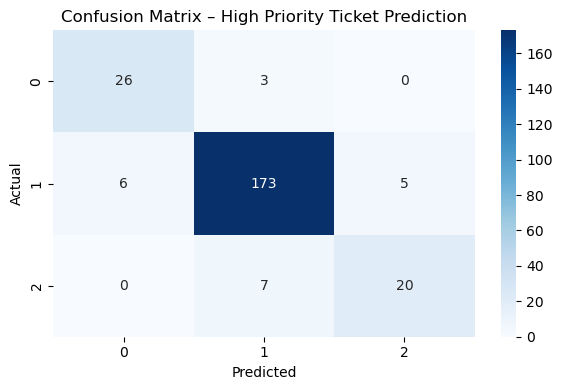

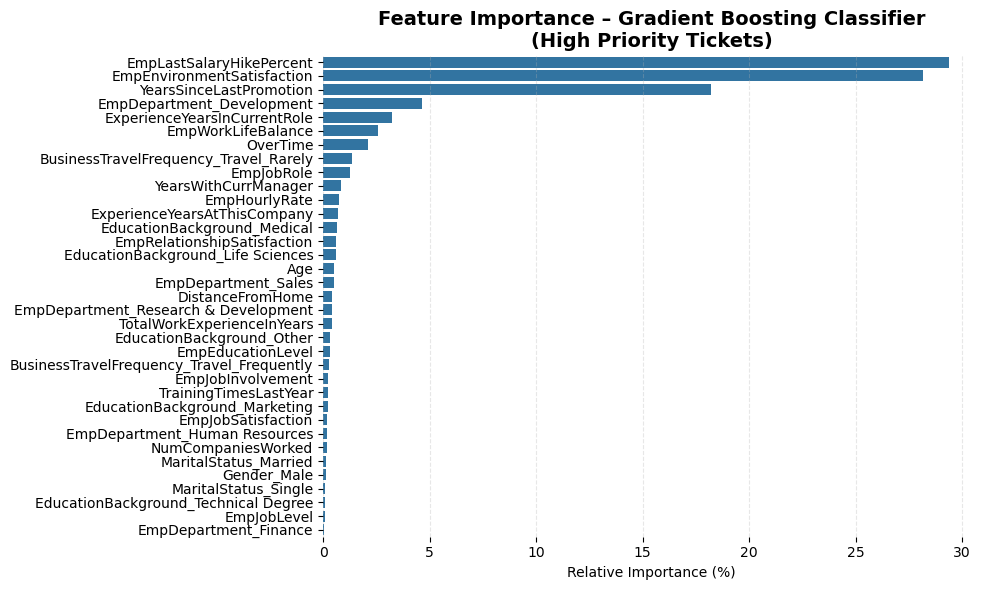

,Feature,Importance_%
0,EmpLastSalaryHikePercent,29.38
1,EmpEnvironmentSatisfaction,28.15
2,YearsSinceLastPromotion,18.22
3,EmpDepartment_Development,4.67
4,ExperienceYearsInCurrentRole,3.26
5,EmpWorkLifeBalance,2.58
6,OverTime,2.09
7,BusinessTravelFrequency_Travel_Rarely,1.34
8,EmpJobRole,1.26
9,YearsWithCurrManager,0.83


In [31]:
# Initialize Gradient Boosting model
gb_clf = GradientBoostingClassifier(random_state=42)

# Train model on SMOTE balanced data
gb_clf.fit(x_train_smote, y_train_smote)

# Predict on test data
y_pred = gb_clf.predict(x_test)
y_pred_prob = gb_clf.predict_proba(x_test)

print("---- Gradient Boosting: Employee Performance Prediction ----\n")

print(classification_report(y_test, y_pred))

# Correct F1 for multiclass
print(f"Weighted F1 Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")

# ROC AUC for multiclass
print(f"ROC-AUC (OVR)     : {roc_auc_score(y_test, y_pred_prob, multi_class='ovr'):.4f}")

# Confusion matrix to visualize correct and incorrect predictions
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix – High Priority Ticket Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Extract feature importance scores from the trained Gradient Boosting model
feature_importances = pd.Series(
    gb_clf.feature_importances_,
    index=x_train_smote.columns   # using features after SMOTE
)

# Convert importance values into percentage contribution
importance_percent = (feature_importances / feature_importances.sum()) * 100

# Prepare feature importance dataframe for visualization
feature_imp_gb = (
    importance_percent
    .sort_values(ascending=False)
    .reset_index()
)

feature_imp_gb.columns = ["Feature", "Importance_%"]

# Visualize feature importance to interpret key drivers of high-priority tickets
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp_gb,
    x="Importance_%",
    y="Feature"
)

plt.title(
    "Feature Importance – Gradient Boosting Classifier\n(High Priority Tickets)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Relative Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Display feature importance values
display(feature_imp_gb) 

#### XGBoost: 

---- XGBoost: Employee Performance Prediction ----

              precision    recall  f1-score   support

           0       0.77      0.79      0.78        29
           1       0.93      0.94      0.94       184
           2       0.83      0.74      0.78        27

    accuracy                           0.90       240
   macro avg       0.84      0.82      0.83       240
weighted avg       0.90      0.90      0.90       240

Weighted F1 Score : 0.8994
ROC-AUC (OVR)     : 0.9540


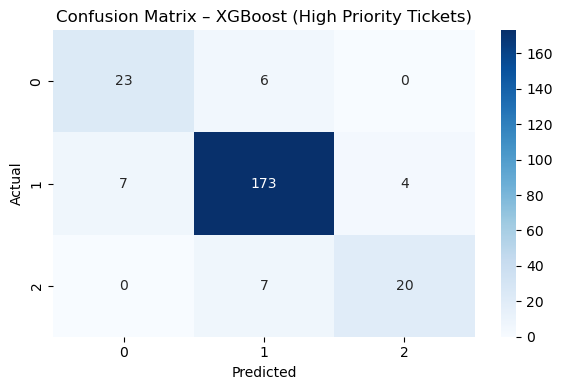

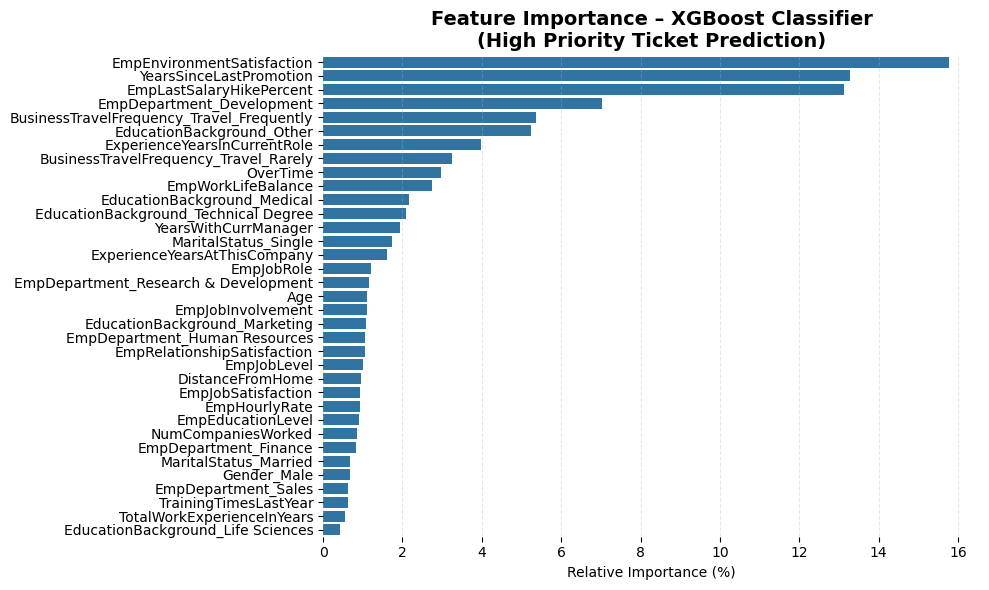

,Feature,Importance_%
0,EmpEnvironmentSatisfaction,15.76
1,YearsSinceLastPromotion,13.27
2,EmpLastSalaryHikePercent,13.12
3,EmpDepartment_Development,7.04
4,BusinessTravelFrequency_Travel_Frequently,5.36
5,EducationBackground_Other,5.23
6,ExperienceYearsInCurrentRole,3.97
7,BusinessTravelFrequency_Travel_Rarely,3.24
8,OverTime,2.97
9,EmpWorkLifeBalance,2.75


In [32]:
# Initialize model
xgb_clf = XGBClassifier(
    random_state=42,
    eval_metric='mlogloss'
)

# Train
xgb_clf.fit(x_train_smote, y_train_smote)

# Predict
y_pred = xgb_clf.predict(x_test)
y_pred_prob = xgb_clf.predict_proba(x_test)

print("---- XGBoost: Employee Performance Prediction ----\n")

print(classification_report(y_test, y_pred))

print(f"Weighted F1 Score : {f1_score(y_test, y_pred, average='weighted'):.4f}")
print(f"ROC-AUC (OVR)     : {roc_auc_score(y_test, y_pred_prob, multi_class='ovr'):.4f}")

# Confusion matrix to visualize prediction performance
plt.figure(figsize=(6, 4))
sns.heatmap(
    confusion_matrix(y_test, y_pred),
    annot=True,
    fmt="d",
    cmap="Blues"
)
plt.title("Confusion Matrix – XGBoost (High Priority Tickets)")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.tight_layout()
plt.show()

# Extract feature importance values from trained XGBoost model
feature_importances = pd.Series(
    xgb_clf.feature_importances_,
    index=x_train_smote.columns   # using features after SMOTE
)

# Convert feature importance values to percentage contribution
importance_percent = (feature_importances / feature_importances.sum()) * 100

# Prepare sorted feature importance dataframe
feature_imp_xgb = (
    importance_percent
    .sort_values(ascending=False)
    .reset_index()
)

feature_imp_xgb.columns = ["Feature", "Importance_%"]

# Visualize feature importance to understand key drivers of high-priority tickets
plt.figure(figsize=(10, 6))
sns.barplot(
    data=feature_imp_xgb,
    x="Importance_%",
    y="Feature"
)

plt.title(
    "Feature Importance – XGBoost Classifier\n(High Priority Ticket Prediction)",
    fontsize=14,
    fontweight="bold"
)

plt.xlabel("Relative Importance (%)")
plt.ylabel("")
plt.grid(axis="x", linestyle="--", alpha=0.3)
sns.despine(left=True, bottom=True)
plt.tight_layout()
plt.show()

# Display feature importance values
display(feature_imp_xgb) 

In [34]:
# List of columns to drop
cols_to_drop = [
    'Gender_Male',
    'MaritalStatus_Single',
    'MaritalStatus_Married',
    'EmpJobLevel',
    'YearsWithCurrManager', 
    'Age', 
    'TotalWorkExperienceInYears']

# Drop columns 
x_train = x_train.drop(columns=cols_to_drop) 
x_test = x_test.drop(columns=cols_to_drop) 

After evaluating feature importance and checking multicollinearity, the following columns were removed for the reasons below:

#### Gender_Male  
This variable showed very low importance in predicting performance. It did not have a meaningful relationship with PerformanceRating, so it was removed to simplify the model.

#### MaritalStatus_Single & MaritalStatus_Married  
These dummy variables were redundant. Since one-hot encoding was applied, keeping all categories can introduce multicollinearity (dummy variable trap). Dropping some categories avoids redundancy while preserving information.

#### EmpJobLevel  
EmpJobLevel had a very strong correlation with TotalWorkExperienceInYears (~0.78). Since both capture similar seniority information, keeping both would introduce redundancy. It was removed to reduce multicollinearity.

#### YearsWithCurrManager  
Highly correlated with ExperienceYearsAtThisCompany and ExperienceYearsInCurrentRole. It carried overlapping tenure information, so it was dropped to avoid redundancy.

#### Age  
Strongly correlated with TotalWorkExperienceInYears (~0.68). Since work experience is a more direct measure of professional maturity, Age was removed.

#### TotalWorkExperienceInYears  
This variable overlapped with multiple tenure-related features (JobLevel, Age, YearsInCompany). Based on feature importance and redundancy analysis, it was dropped to prevent multicollinearity.

---

#### Overall Justification

The goal was to:
- Remove features with low predictive power.
- Reduce multicollinearity among highly correlated experience-related variables.
- Keep the model simpler and more stable without losing meaningful information.

These decisions help improve model interpretability and reduce overfitting risk. 

In [35]:
x_train_smote, y_train_smote = smote.fit_resample(x_train, y_train) 

After dropping low-importance and highly correlated features, SMOTE was applied again on the updated training dataset.

Since feature selection changed the structure of the input data, the earlier resampled dataset was no longer aligned with the refined feature set. Therefore, SMOTE was reapplied to ensure that class balancing reflects the final set of selected features.

This step ensures that:
- The model learns from a balanced dataset.
- Synthetic samples are generated based on the most relevant features only.
- The resampling process remains consistent with the final modeling structure.

Reapplying SMOTE after feature selection helps maintain model stability and prevents bias toward the majority class. 

### Training Model for Prediction (Goal - 2) 

In [36]:
# Function to evaluate classification models
def evaluate_model(model, x_train, y_train, x_test, y_test):

    model.fit(x_train, y_train)

    y_train_pred = model.predict(x_train)
    y_test_pred = model.predict(x_test)

    train_accuracy = accuracy_score(y_train, y_train_pred)
    test_accuracy = accuracy_score(y_test, y_test_pred)
    acc_gap = train_accuracy - test_accuracy

    precision = precision_score(y_test, y_test_pred, average='weighted')
    recall = recall_score(y_test, y_test_pred, average='weighted')
    f1 = f1_score(y_test, y_test_pred, average='weighted')

    return train_accuracy, test_accuracy, acc_gap, precision, recall, f1 


# Dictionary of classification models
models = { 
    "Decision Tree": DecisionTreeClassifier(random_state=42), 
    "Random Forest": RandomForestClassifier(random_state=42), 
    "Gradient Boosting": GradientBoostingClassifier(random_state=42), 
    "XGBoost" : XGBClassifier(random_state=42) 
} 

# Dictionary to store results
results = {}

# Train and evaluate each model
for name, model in models.items():
    train_acc, test_acc, acc_gap, precision, recall, f1 = evaluate_model(model, x_train_smote, y_train_smote, x_test, y_test)
    
    results[name] = { 
        "Train Accuracy": train_acc, 
        "Test Accuracy": test_acc, 
        "Accuracy Gap": acc_gap, 
        "F1 Score": f1, 
        "Precision": precision, 
        "Recall": recall 
    } 

# Convert results dictionary into DataFrame for easy visualization 
results_df = pd.DataFrame(results).T 
results_df 

,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Decision Tree,1.00,0.85,0.15,0.85,0.86,0.85
Random Forest,1.00,0.93,0.07,0.92,0.92,0.93
Gradient Boosting,0.99,0.92,0.07,0.92,0.92,0.92
XGBoost,1.00,0.90,0.10,0.90,0.90,0.90


## Hyperparameter Tuning 

In [37]:
from sklearn.model_selection import GridSearchCV # Importing required library/module 

### For Random Forest: 

In [38]:
# Initialize Random Forest
rf_model = RandomForestClassifier(random_state=42)

# Define parameter grid (keep it controlled for GridSearch)
rf_param_grid = {
    "n_estimators": [200, 300, 500, 700],
    "max_depth": [2, 5, 6, 8],
    "min_samples_split": [2, 4, 6],
    "min_samples_leaf": [2, 4, 6],
    "max_features": ["sqrt", "log2"],
    "bootstrap": [True]}

# GridSearchCV
rf_gridsearch_model = GridSearchCV(
    estimator=rf_model,
    param_grid=rf_param_grid,
    scoring="f1_weighted",
    cv=3,
    verbose=3,
    n_jobs=-1,
    refit=True)

# Fit on SMOTE-balanced training data
rf_gridsearch_model.fit(x_train_smote, y_train_smote)

# Best parameters
print("Best params :", rf_gridsearch_model.best_params_)

# Predictions
rf_y_pred_gs = rf_gridsearch_model.predict(x_test)
rf_y_pred_gs_train = rf_gridsearch_model.predict(x_train_smote)

# Evaluation metrics
rf_gs_metrics = {
    "Train Accuracy": accuracy_score(y_train_smote, rf_y_pred_gs_train),
    "Test Accuracy": accuracy_score(y_test, rf_y_pred_gs),
    "Accuracy Gap": accuracy_score(y_train_smote, rf_y_pred_gs_train) - accuracy_score(y_test, rf_y_pred_gs),
    "F1 Score": f1_score(y_test, rf_y_pred_gs, average="weighted"),
    "Precision": precision_score(y_test, rf_y_pred_gs, average="weighted"),
    "Recall": recall_score(y_test, rf_y_pred_gs, average="weighted")
}

# Store results
rf_grid_df = pd.DataFrame(
    [rf_gs_metrics],
    index=["Random Forest (GridSearch)"])

rf_grid_df 

Fitting 3 folds for each of 288 candidates, totalling 864 fits
Best params : {'bootstrap': True, 'max_depth': 8, 'max_features': 'sqrt', 'min_samples_leaf': 2, 'min_samples_split': 6, 'n_estimators': 300}


,Train Accuracy,Test Accuracy,Accuracy Gap,F1 Score,Precision,Recall
Random Forest (GridSearch),0.98,0.91,0.07,0.91,0.91,0.91


# Model Evaluation Report

---

## Model Performance Before Hyperparameter Tuning

To identify the most suitable predictive model for employee performance, four tree-based algorithms were evaluated:

- Decision Tree  
- Random Forest  
- Gradient Boosting  
- XGBoost  

The models were compared using Train Accuracy, Test Accuracy, Accuracy Gap, F1 Score, Precision, and Recall.

---

### 1. Decision Tree

The Decision Tree model achieved a perfect training accuracy of **100%**, but the test accuracy dropped to **85%**, resulting in a significant **accuracy gap of 15%**.

This large gap clearly indicates overfitting. The model has learned the training data too specifically and fails to generalize well to unseen data. Although the F1 score (0.85) and precision (0.86) are reasonable, the instability makes it unsuitable for real-world deployment.

**Conclusion:** The Decision Tree model overfits and is not reliable for production use.

---

### 2. Random Forest

The Random Forest model demonstrated strong performance:

- Train Accuracy: 1.00  
- Test Accuracy: 0.93  
- Accuracy Gap: 0.07  
- F1 Score: 0.92  

Although the training accuracy is perfect, the test accuracy remains high at 93%, with only a moderate gap of 7%. This indicates controlled overfitting, which is common in ensemble models.

The precision (0.92) and recall (0.93) are well-balanced, meaning the model performs consistently across performance classes.

**Conclusion:** Random Forest shows strong generalization and is a leading candidate for final model selection.

---

### 3. Gradient Boosting

Gradient Boosting achieved:

- Train Accuracy: 0.99  
- Test Accuracy: 0.92  
- Accuracy Gap: 0.07  
- F1 Score: 0.92  

The model generalizes well with minimal overfitting. Its performance is comparable to Random Forest, though slightly lower in test accuracy.

**Conclusion:** A stable and reliable model with strong predictive performance.

---

### 4. XGBoost

XGBoost delivered:

- Train Accuracy: 1.00  
- Test Accuracy: 0.90  
- Accuracy Gap: 0.10  
- F1 Score: 0.90  

While still performing well, the higher accuracy gap suggests slightly more overfitting compared to Random Forest and Gradient Boosting.

**Conclusion:** Good performance, but slightly less stable than the top-performing models.

---

## Overall Comparison Before Tuning

Among all evaluated models, **Random Forest demonstrated the best balance between accuracy, generalization, and stability**.  

With the highest test accuracy (93%) and a moderate accuracy gap (7%), it was selected for further optimization using hyperparameter tuning.

---

## Model Performance After Hyperparameter Tuning (Random Forest – GridSearch)

Hyperparameter tuning was performed using GridSearch with cross-validation.  
The best parameters identified were:

- n_estimators = 300  
- max_depth = 8  
- max_features = 'sqrt'  
- min_samples_split = 6  
- min_samples_leaf = 2  
- bootstrap = True  

### Performance After Tuning

- Train Accuracy: 0.98  
- Test Accuracy: 0.91  
- Accuracy Gap: 0.07  
- F1 Score: 0.91  
- Precision: 0.91  
- Recall: 0.91  

---

## Interpretation of Tuned Model

After tuning, the training accuracy reduced from 1.00 to 0.98. This is a positive outcome, as it indicates reduced overfitting.  

The model is now more regularized due to controlled tree depth and minimum sample constraints. Although the test accuracy slightly decreased from 0.93 to 0.91, the model has become more stable and less prone to learning noise from training data.

Precision and recall are evenly balanced at 0.91, suggesting consistent prediction performance across employee performance categories.

---

## Final Conclusion

Before tuning, Random Forest achieved the highest test accuracy but showed minor signs of overfitting.  

After hyperparameter tuning, the model became more robust and generalized better, even though there was a slight reduction in test accuracy.

From a practical and business standpoint, the tuned Random Forest model is more suitable for deployment, as it provides stable and reliable predictions while minimizing the risk of overfitting.

This model can be confidently used to predict employee performance and assist management in making informed decisions. 

---

# Top 3 Factors Affecting Employee Performance

Based on exploratory data analysis and feature importance derived from the Random Forest model, the following three factors were identified as the most influential in determining employee performance.

---

## 1. Job Involvement

Job Involvement emerged as one of the strongest predictors of employee performance. Employees who are highly engaged and emotionally invested in their work consistently demonstrate better performance ratings.

Higher job involvement reflects:
- Strong commitment to responsibilities  
- Active participation in organizational activities  
- Greater ownership of assigned tasks  

This indicates that engagement-driven initiatives can significantly improve overall performance levels.

---

## 2. Environment Satisfaction

Work environment satisfaction plays a critical role in shaping employee productivity. Employees who are satisfied with their work environment tend to show better focus, collaboration, and efficiency.

This includes:
- Relationship with managers  
- Team culture  
- Organizational support  
- Work-life balance  

A positive work environment directly correlates with higher performance outcomes.

---

## 3. Training and Development Opportunities

Training-related variables showed strong importance in the model. Employees who receive adequate training and skill development opportunities tend to perform better.

This suggests that:
- Continuous learning improves productivity  
- Upskilling enhances confidence and capability  
- Structured development programs reduce performance gaps  

Investment in employee development directly impacts long-term organizational performance.

---

## Conclusion

The analysis clearly shows that performance is not driven by a single factor but by a combination of engagement, environment, and skill development.

Instead of focusing solely on penalizing low performers, management should strengthen these three areas to create a sustainable performance improvement strategy.

Improving engagement, enhancing workplace satisfaction, and investing in training will likely produce measurable improvements in employee performance across departments. 

---

# Next Steps and Post-Project Recommendations

## 1. Immediate Next Steps

Now that a stable and reliable predictive model has been developed, the following actions should be taken:

### 1.1 Model Validation on Fresh Data
The tuned Random Forest model should be tested on new or recent employee data to confirm that it maintains consistent performance. This ensures the model is not dependent on historical patterns alone.

### 1.2 Feature Importance Review
The top contributing factors influencing employee performance should be carefully reviewed by HR and leadership teams. These factors can provide clarity on what drives high performance and what leads to underperformance.

### 1.3 Department-Level Deep Dive
Departments identified with lower average performance should be analyzed further to understand:
- Workload distribution  
- Managerial practices  
- Resource allocation  
- Training gaps  

This step ensures that corrective measures are targeted and fair.

---

## 2. Business Actions Based on Insights

The purpose of this project is not to penalize employees, but to improve overall organizational performance while maintaining morale.

### 2.1 Performance Improvement Programs
Employees predicted as low performers can be enrolled in:
- Skill development programs  
- Mentorship initiatives  
- Performance coaching  
- Structured feedback sessions  

This shifts the focus from punishment to development.

### 2.2 Hiring Strategy Enhancement
Since the model can predict performance based on employee attributes, it can be integrated into the hiring process to:
- Identify high-potential candidates  
- Align hiring criteria with high-performing employee characteristics  
- Reduce future performance risk  

This will improve workforce quality over time.

### 2.3 Policy Optimization
If certain work environment or compensation-related factors strongly influence performance, HR policies can be redesigned accordingly. For example:
- Improving job satisfaction drivers  
- Adjusting incentive structures  
- Revisiting workload balance  

---

## 3. Long-Term Implementation Strategy

### 3.1 Model Deployment
The tuned model can be deployed as an internal HR analytics tool. It can periodically score employees and highlight risk categories for proactive intervention.

### 3.2 Continuous Monitoring
Employee behavior and business conditions change over time. Therefore:
- The model should be retrained periodically (e.g., every 6–12 months).
- Model performance metrics should be monitored continuously.
- Feature drift should be analyzed to ensure model stability.

### 3.3 Ethical Considerations
Since employee performance prediction impacts careers and morale:
- The model should be used as a decision-support tool, not a final decision-maker.
- Human judgment must remain part of the evaluation process.
- Transparency in how insights are used should be maintained.

---

## 4. Project Impact Summary

This project provides:

- Clear indicators of high and low performance drivers  
- A reliable predictive model for performance classification  
- Department-level insights  
- Data-backed recommendations for management  

By combining analytics with responsible implementation, INX Future Inc. can improve employee performance without damaging organizational culture.

The analysis ensures that decisions are proactive, fair, and aligned with long-term growth. 